In [13]:
import yfinance as yf
data = yf.download("AAPL", start="2026-02-01")
print(data.head())


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-02-02  269.509308  269.988398  258.729317  259.547804  73913400
2026-02-03  268.980286  271.375829  267.113728  268.700806  64394700
2026-02-04  275.977234  278.432694  271.785041  271.785041  90545700
2026-02-05  275.398346  278.981685  272.723323  277.614230  52977400
2026-02-06  277.604218  280.389052  276.416422  276.606072  50453400


# Stock Market Regime Identification Using Hidden Markov Models

# Chapter 1 Introduction to Hidden Markov Model

---

##  1.1 Project Objective

The objective of this project is to identify hidden market regimes using a **Gaussian Hidden Markov Model (Gaussian HMM)**.

Financial markets are dynamic systems whose statistical characteristics may change over time. Different periods may exhibit different combinations of return, volatility, momentum, and trend behaviour.

However, these underlying market conditions cannot be directly observed.

Instead, measurable financial indicators are used to infer the hidden market states.

In this project, the main observed financial features are:

- Log Return
- Volatility
- Momentum
- Moving Average Gap

The main research workflow is:

> **Historical Market Data → Feature Engineering → Data Standardization → Gaussian HMM Training → Hidden State Identification → State Analysis → Market Regime Forecasting**

---

##  1.2 Hidden Markov Model

A **Hidden Markov Model (HMM)** is a probabilistic model for sequential data.

The model assumes that an observed time series is generated by an underlying sequence of hidden states.

At each time point \(t\), the model contains:

1. a hidden state \(S_t\);
2. an observation vector \(X_t\).

The relationship can be expressed conceptually as:

$$
S_t
\longrightarrow
X_t
$$

where the hidden state influences the statistical distribution of the observed financial variables.

---

##  1.3 Hidden State

The hidden state represents an unobservable statistical market regime.

It is denoted by:

$$
S_t
$$

where:

- \(t\) represents time;
- \(S_t\) represents the hidden market state at time \(t\).

In this project, a three-state Gaussian HMM is used:

$$
S_t \in \{0,1,2\}
$$

Therefore, the model identifies three latent states:

- State 0
- State 1
- State 2

### Important Note

The numerical state labels do **not** have predefined economic meanings.

Therefore, the following relationship is **not assumed before model estimation**:

$$
State\ 0 = Bear,\qquad
State\ 1 = Sideways,\qquad
State\ 2 = Bull
$$

The HMM discovers statistical regimes from the observed data.

After model training, the economic meaning of each state is interpreted by analysing its financial characteristics, including:

- Mean Log Return
- Mean Volatility
- Mean Momentum
- Mean Moving Average Gap

Therefore, the interpretation process follows:

$$
\text{HMM Estimation}
\rightarrow
\text{State Identification}
\rightarrow
\text{Statistical Analysis}
\rightarrow
\text{Economic Interpretation}
$$

---

##  1.4 Observation Vector

The observation vector contains the financial variables that can be directly calculated from historical market data.

The observation vector at time \(t\) is defined as:

$$
X_t=
\begin{bmatrix}
r_t\\
\sigma_t\\
M_t\\
G_t
\end{bmatrix}
$$

where:

$$
r_t = \text{Log Return}
$$

$$
\sigma_t = \text{Volatility}
$$

$$
M_t = \text{Momentum}
$$

$$
G_t = \text{Moving Average Gap}
$$

These variables describe different aspects of market behaviour.

| Feature | Financial Meaning |
|---|---|
| Log Return | Direction and magnitude of price movement |
| Volatility | Market risk and fluctuation intensity |
| Momentum | Strength of recent price movement |
| MA Gap | Deviation of price from its moving average trend |

The HMM uses the joint behaviour of these features to distinguish different hidden market regimes.

---

##  1.5 Markov Property

The fundamental assumption of a first-order HMM is that the current hidden state depends only on the immediately previous hidden state.

Mathematically:

$$
P(S_t \mid S_{t-1},S_{t-2},\ldots,S_1)
=
P(S_t \mid S_{t-1})
$$

This assumption is called the **Markov Property**.

### Interpretation

Instead of modelling the dependence of the current state on the entire historical state sequence, the first-order Markov assumption simplifies the relationship to:

$$
S_{t-1}
\longrightarrow
S_t
\longrightarrow
S_{t+1}
$$

This makes the model computationally manageable while allowing persistent and changing market regimes to be represented probabilistically.

---

##  1.6 Transition Probability

The probability of moving from one hidden state to another is represented by the **transition matrix**.

The transition matrix is defined as:

$$
A=[a_{ij}]
$$

where:

$$
a_{ij}
=
P(S_{t+1}=j \mid S_t=i)
$$

This represents the probability that the market moves from State \(i\) at time \(t\) to State \(j\) at time \(t+1\).

For an HMM with \(N\) hidden states:

$$
\sum_{j=1}^{N}a_{ij}=1
$$

because the probabilities of all possible next states must sum to one.

For a three-state HMM, an example transition matrix is:

$$
A=
\begin{bmatrix}
0.90 & 0.08 & 0.02\\
0.05 & 0.90 & 0.05\\
0.02 & 0.08 & 0.90
\end{bmatrix}
$$

For example:

$$
a_{01}
=
P(S_{t+1}=1 \mid S_t=0)
$$

represents the probability of transitioning from State 0 to State 1.

The actual transition matrix in this project is **not predefined**. It is estimated from the financial data during model training.

---

##  1.7 Gaussian Emission Distribution

The HMM must describe how each hidden state generates observable financial data.

In a Gaussian HMM, the observation vector is assumed to follow a state-dependent multivariate Gaussian distribution.

For hidden state \(i\):

$$
X_t \mid S_t=i
\sim
\mathcal{N}(\mu_i,\Sigma_i)
$$

where:

- \(\mu_i\) is the mean vector of State \(i\);
- \(\Sigma_i\) is the covariance matrix of State \(i\).

The mean vector can be written as:

$$
\mu_i=
\begin{bmatrix}
\mu_{r,i}\\
\mu_{\sigma,i}\\
\mu_{M,i}\\
\mu_{G,i}
\end{bmatrix}
$$

Each state therefore represents a different statistical pattern in the financial feature space.

For example, different states may exhibit different combinations of:

- relatively high or low average return;
- relatively high or low volatility;
- positive or negative momentum;
- positive or negative deviation from the moving average.

The economic meaning of each state is interpreted **after model estimation**, rather than assigned before training.

---

##  1.8 Main Components of the Gaussian HMM

The Gaussian HMM used in this project can be represented by the parameter set:

$$
\lambda=
(\pi,A,\mu,\Sigma)
$$

where:

$$
\pi
=
\text{Initial State Probability}
$$

$$
A
=
\text{Transition Matrix}
$$

$$
\mu
=
\text{State Mean Parameters}
$$

$$
\Sigma
=
\text{State Covariance Parameters}
$$

These parameters are estimated from the observed financial feature sequence.

The detailed training process, including the **Forward Algorithm**, **Backward Algorithm**, and **Baum–Welch Algorithm**, will be introduced in Chapter 5.

---

##  1.9 Project Workflow

The complete research workflow is:

### Step 1 — Financial Data Collection

Historical stock market data is collected.

$$
P_1,P_2,\ldots,P_T
$$

↓

### Step 2 — Feature Engineering

Financial indicators are constructed from the raw price series.

$$
X_t=
\begin{bmatrix}
r_t\\
\sigma_t\\
M_t\\
G_t
\end{bmatrix}
$$

↓

### Step 3 — Data Standardization

Features with different scales are transformed into comparable standardized values.

↓

### Step 4 — Gaussian HMM Training

The Gaussian HMM estimates:

$$
\lambda=
(\pi,A,\mu,\Sigma)
$$

↓

### Step 5 — Hidden State Identification

The model identifies a sequence of hidden states:

$$
S_1,S_2,\ldots,S_T
$$

↓

### Step 6 — State Analysis

The statistical characteristics of each hidden state are analysed.

↓

### Step 7 — Transition Analysis

The transition matrix is used to study how market regimes evolve over time.

↓

### Step 8 — Market Regime Forecasting

The trained HMM is used for one-step and multi-step state probability forecasting.

---

##  1.10 Chapter Summary

This project uses a three-state Gaussian Hidden Markov Model to identify latent statistical regimes in financial market data.

The model does not assume in advance that:

$$
State\ 0 = Bear,\qquad
State\ 1 = Sideways,\qquad
State\ 2 = Bull
$$

Instead, the model learns three hidden states from the joint behaviour of:

$$
X_t=
\begin{bmatrix}
LogReturn_t\\
Volatility_t\\
Momentum_t\\
MAGap_t
\end{bmatrix}
$$

The economic meaning of each state is determined after training through statistical analysis and empirical interpretation.

Therefore, the central idea of the project is:

$$
\boxed{
\text{Observed Financial Features}
\rightarrow
\text{Gaussian HMM}
\rightarrow
\text{Hidden Statistical Regimes}
}
$$

In [1]:
# Chapter 1 Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import yfinance as yf

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import datetime

from sklearn.preprocessing import StandardScaler

from hmmlearn.hmm import GaussianHMM

# Chapter 2 Financial Data Collection

---

##  Objective

The objective of this chapter is to collect historical stock price data and transform raw market data into a suitable format for modelling.

---

#  Stock Price

The observed stock price is represented as:

$$
P_t
$$

where:

- \(P_t\) represents the closing price at time \(t\).

However, stock price itself is usually not stationary.

Therefore, financial modelling commonly uses price changes rather than absolute prices.

---

#  Daily Return

The daily return is calculated as:

$$
R_t=
\frac{P_t-P_{t-1}}
{P_{t-1}}
$$


where:

- \(P_t\): current price
- \(P_{t-1}\): previous price


---

#  Log Return

The logarithmic return is defined as:

$$
r_t=
\log(1+R_t)
$$


Log return is preferred because:

1. It is approximately normally distributed.
2. It can be accumulated over time.
3. It is suitable for Gaussian models.


---

#  Data Processing Algorithm


Raw Stock Price

↓

Calculate Daily Return

↓

Calculate Log Return

↓

Remove Missing Values

↓

Generate Observation Data


---

#  Interpretation

The output of this chapter is the observed financial sequence:

$$
X_1,X_2,...,X_T
$$

which will be used as input for the Gaussian HMM.

In [2]:
# Chapter 2 Financial Data Collection

def get_stock_data(
    ticker="AAPL",
    start="2016-01-01",
    end=None
):
    
    if end is None:
        end = datetime.today().strftime("%Y-%m-%d")
        
    data = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )
    
    if data.empty:
        raise ValueError(f"No data downloaded for {ticker}")
    
    # Remove MultiIndex if exists
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    
    return data


In [3]:
ticker = "AAPL"

data = get_stock_data(ticker)

data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,23.688671,23.693169,22.935401,23.072564,270597600
2016-01-05,23.095049,23.801099,23.027593,23.778614,223164000
2016-01-06,22.643089,23.018602,22.456459,22.611609,273829600
2016-01-07,21.687449,22.514922,21.682952,22.188880,324377600
2016-01-08,21.802122,22.285565,21.757151,22.159645,283192000


# Chapter 3 Feature Engineering

---

##  Objective

The objective of feature engineering is to transform raw stock prices into meaningful financial indicators.

The Gaussian HMM does not use raw prices directly.

Instead, it learns hidden states from a feature vector.

---

#  Observation Vector

The feature vector is:

$$
X_t=
\begin{bmatrix}
r_t\\
\sigma_t\\
M_t\\
G_t
\end{bmatrix}
$$


where:

- \(r_t\): Log Return
- \(\sigma_t\): Volatility
- \(M_t\): Momentum
- \(G_t\): Moving Average Gap


---

# 1. Log Return


$$
r_t=
\log(1+R_t)
$$


Meaning:

Measures the direction and magnitude of daily price movement.


---

# 2. Volatility


Volatility measures market risk.


The rolling standard deviation is:

$$
\sigma_t
=
\sqrt{
\frac{1}{n-1}
\sum_{i=0}^{n-1}
(R_{t-i}-\bar R)^2
}
$$


where:

- \(n\) is the rolling window size.
- \(\bar R\) is the average return.


In this project:

$$
n=5
$$


---

# 3. Momentum


Momentum measures recent price movement strength.


$$
Momentum_t
=
P_t-P_{t-k}
$$


Positive momentum:

$$
Momentum_t>0
$$

indicates upward movement.


Negative momentum:

$$
Momentum_t<0
$$

indicates downward movement.


---

# 4. Moving Average Gap


The moving average is:

$$
MA_t=
\frac{1}{n}
\sum_{i=0}^{n-1}P_{t-i}
$$


The Moving Average Gap is:

$$
MAGap_t
=
P_t-MA_t
$$


Interpretation:

$$
MAGap_t>0
$$

Price is above trend.


$$
MAGap_t<0
$$

Price is below trend.


---

#  Feature Engineering Workflow


Stock Price

↓

Return Calculation

↓

Log Return

↓

Volatility

↓

Momentum

↓

Moving Average Gap

↓

Feature Matrix


$$
X=
\begin{bmatrix}
r_1&\sigma_1&M_1&G_1\\
r_2&\sigma_2&M_2&G_2\\
...&...&...&...
\end{bmatrix}
$$


---

#  Interpretation

The engineered features describe different aspects of market behaviour:

|Feature|Meaning|
|-|-|
|Log Return|Market movement|
|Volatility|Risk level|
|Momentum|Price strength|
|MA Gap|Trend deviation|

These features provide sufficient information for HMM to identify different market regimes.

In [4]:
# Chapter 3 Feature Engineering

def feature_engineering(data):
    
    data = data.copy()
    
    price = data["Close"]
    
    # Simple Return
    data["Return"] = price.pct_change()
    
    # Log Return
    data["LogReturn"] = np.log1p(data["Return"])
    
    # 5-day Rolling Volatility
    data["Volatility"] = data["Return"].rolling(5).std()
    
    # 5-day Momentum
    data["Momentum"] = price - price.shift(5)
    
    # 20-day Moving Average
    data["MA20"] = price.rolling(20).mean()
    
    # Moving Average Gap
    data["MAGap"] = price - data["MA20"]
    
    data.dropna(inplace=True)
    
    return data

In [5]:
data = feature_engineering(data)

data.head()

Price,Close,High,Low,Open,Volume,Return,LogReturn,Volatility,Momentum,MA20,MAGap
Date,,,,,,,,,,,
2016-02-01,21.682953,21.745913,21.451351,21.691947,163774000,-0.009349,-0.009392,0.037166,-0.676811,22.109952,-0.426999
2016-02-02,21.244480,21.595256,21.199508,21.455844,149428800,-0.020222,-0.020429,0.037028,-1.238958,21.987742,-0.743262
2016-02-03,21.664963,21.775142,21.154538,21.361406,183857200,0.019793,0.019599,0.021958,0.658833,21.916238,-0.251275
2016-02-04,21.839039,22.004076,21.520271,21.671742,185886800,0.008035,0.008003,0.021969,0.682259,21.876035,-0.036997
2016-02-05,21.255760,21.911384,21.181156,21.820953,185672400,-0.026708,-0.027071,0.019391,-0.631809,21.854451,-0.598691


# Chapter 4 Data Standardization

---

##  4.1 Objective

The objective of this chapter is to standardize the financial features before training the Gaussian Hidden Markov Model.

The observation vector used in this project is:

$$
X_t=
\begin{bmatrix}
LogReturn_t\\
Volatility_t\\
Momentum_t\\
MAGap_t
\end{bmatrix}
$$

These features have different numerical scales.

For example:

- Log Return may be close to \(0.01\);
- Volatility may be close to \(0.02\);
- Momentum may have a much larger numerical range;
- MA Gap depends on the price level of the stock.

Without standardization, variables with larger numerical scales may have excessive influence on model estimation.

---

##  4.2 Why Standardization is Required

Suppose that two features have very different scales:

$$
LogReturn_t=0.01
$$

and:

$$
Momentum_t=5.00
$$

The numerical scale of Momentum is much larger than that of Log Return.

However, a larger numerical value does not necessarily mean that the feature is economically more important.

Therefore, all input features are standardized before HMM training.

---

##  4.3 Standardization Formula

For feature \(j\), the standardized value is calculated as:

$$
z_{t,j}
=
\frac{x_{t,j}-\mu_j}
{\sigma_j}
$$

where:

- \(x_{t,j}\) is the original value of feature \(j\) at time \(t\);
- \(\mu_j\) is the sample mean of feature \(j\);
- \(\sigma_j\) is the sample standard deviation of feature \(j\);
- \(z_{t,j}\) is the standardized value.

After standardization, each feature has approximately:

$$
E[Z_j]\approx 0
$$

and:

$$
Std(Z_j)\approx 1
$$

---

##  4.4 Original and Standardized Feature Matrices

Before standardization, the feature matrix is:

$$
X=
\begin{bmatrix}
r_1 & \sigma_1 & M_1 & G_1\\
r_2 & \sigma_2 & M_2 & G_2\\
\vdots & \vdots & \vdots & \vdots\\
r_T & \sigma_T & M_T & G_T
\end{bmatrix}
$$

After standardization:

$$
Z=
\begin{bmatrix}
z_{1,1} & z_{1,2} & z_{1,3} & z_{1,4}\\
z_{2,1} & z_{2,2} & z_{2,3} & z_{2,4}\\
\vdots & \vdots & \vdots & \vdots\\
z_{T,1} & z_{T,2} & z_{T,3} & z_{T,4}
\end{bmatrix}
$$

In the Python implementation, this standardized matrix is stored as:

`X_scaled`

and is used as the input to the Gaussian HMM.

---

##  4.5 Standardization Workflow

The standardization process is:

**Step 1 — Select Features**

$$
X_t=
\begin{bmatrix}
LogReturn_t\\
Volatility_t\\
Momentum_t\\
MAGap_t
\end{bmatrix}
$$

↓

**Step 2 — Calculate Feature Mean and Standard Deviation**

$$
\mu_j
\qquad \text{and} \qquad
\sigma_j
$$

↓

**Step 3 — Apply Standardization**

$$
z_{t,j}
=
\frac{x_{t,j}-\mu_j}
{\sigma_j}
$$

↓

**Step 4 — Generate Standardized Feature Matrix**

$$
X_{scaled}
$$

↓

**Step 5 — Train Gaussian HMM**

---

##  4.6 Interpretation

Standardization does not change the chronological order of observations or the underlying market information.

Its purpose is to place all features on comparable numerical scales.

The transformation can be summarized as:

$$
\boxed{
X
\longrightarrow
StandardScaler
\longrightarrow
X_{scaled}
}
$$

The Gaussian HMM is then trained using:

$$
X_{scaled}
$$

rather than the original unscaled feature matrix.

---

##  4.7 Chapter Summary

This chapter standardizes the four financial features before HMM estimation.

The transformation is:

$$
\boxed{
z_{t,j}
=
\frac{x_{t,j}-\mu_j}
{\sigma_j}
}
$$

This prevents features with larger numerical scales from dominating the estimation process and improves the numerical stability of model training.

In [6]:
data.head()

Price,Close,High,Low,Open,Volume,Return,LogReturn,Volatility,Momentum,MA20,MAGap
Date,,,,,,,,,,,
2016-02-01,21.682953,21.745913,21.451351,21.691947,163774000,-0.009349,-0.009392,0.037166,-0.676811,22.109952,-0.426999
2016-02-02,21.244480,21.595256,21.199508,21.455844,149428800,-0.020222,-0.020429,0.037028,-1.238958,21.987742,-0.743262
2016-02-03,21.664963,21.775142,21.154538,21.361406,183857200,0.019793,0.019599,0.021958,0.658833,21.916238,-0.251275
2016-02-04,21.839039,22.004076,21.520271,21.671742,185886800,0.008035,0.008003,0.021969,0.682259,21.876035,-0.036997
2016-02-05,21.255760,21.911384,21.181156,21.820953,185672400,-0.026708,-0.027071,0.019391,-0.631809,21.854451,-0.598691


In [7]:
# Chapter 4 Feature Standardization

FEATURES = [
    "LogReturn",
    "Volatility",
    "Momentum",
    "MAGap"
]

X = data[FEATURES]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
print(pd.DataFrame(
    X_scaled,
    columns=FEATURES
).head())

   LogReturn  Volatility  Momentum     MAGap
0  -0.572833    2.129796 -0.208938 -0.238668
1  -1.181320    2.116437 -0.305151 -0.290492
2   1.025560    0.651731  0.019661 -0.209874
3   0.386217    0.652810  0.023671 -0.174762
4  -1.547508    0.402226 -0.201236 -0.266802


In [9]:
print(pd.DataFrame(
    X_scaled,
    columns=FEATURES
).describe())

          LogReturn    Volatility      Momentum        MAGap
count  2.655000e+03  2.655000e+03  2.655000e+03  2655.000000
mean  -1.739558e-17  3.746741e-17  8.028731e-18     0.000000
std    1.000188e+00  1.000188e+00  1.000188e+00     1.000188
min   -7.647210e+00 -1.394127e+00 -8.729404e+00    -6.589222
25%   -4.483373e-01 -6.614703e-01 -3.504418e-01    -0.414678
50%    5.440050e-03 -2.407534e-01 -2.128773e-02    -0.032163
75%    4.945473e-01  3.710480e-01  3.779527e-01     0.441900
max    7.807892e+00  8.947213e+00  5.632152e+00     4.682593


# Chapter 5 Gaussian Hidden Markov Model Training

---

## 5.1 Objective

The objective of this chapter is to train a three-state Gaussian Hidden Markov Model using the standardized financial feature sequence.

The model learns:

1. the initial state probabilities;
2. the transition probabilities;
3. the mean vector of each hidden state;
4. the covariance matrix of each hidden state.

The trained model is then used to estimate the hidden state sequence.

---

##  5.2 Gaussian HMM Structure

A Gaussian HMM can be represented by:

$$
\lambda=
(\pi,A,\mu,\Sigma)
$$

where:

- \(\pi\): initial state probability distribution;
- \(A\): state transition matrix;
- \(\mu\): state-dependent mean parameters;
- \(\Sigma\): state-dependent covariance parameters.

The model contains three main probability components:

$$
\boxed{
\text{Initial Probability}
+
\text{Transition Probability}
+
\text{Emission Probability}
}
$$

---

## 1. Initial State Probability

The initial state probability is:

$$
\pi_i
=
P(S_1=i)
$$

For a three-state model:

$$
\pi=
\begin{bmatrix}
\pi_0 & \pi_1 & \pi_2
\end{bmatrix}
$$

with:

$$
\sum_{i=0}^{2}\pi_i=1
$$

This describes the probability of the observation sequence beginning in each hidden state.

---

## 2. Transition Probability

The transition probability is:

$$
a_{ij}
=
P(S_{t+1}=j \mid S_t=i)
$$

The complete transition matrix is:

$$
A=
\begin{bmatrix}
a_{00} & a_{01} & a_{02}\\
a_{10} & a_{11} & a_{12}\\
a_{20} & a_{21} & a_{22}
\end{bmatrix}
$$

Each row satisfies:

$$
\sum_{j=0}^{2}a_{ij}=1
$$

A large diagonal element:

$$
a_{ii}
$$

indicates that State \(i\) has strong persistence.

---

## 3. Gaussian Emission Probability

The observation vector is:

$$
X_t=
\begin{bmatrix}
r_t\\
\sigma_t\\
M_t\\
G_t
\end{bmatrix}
$$

Conditional on hidden state \(i\):

$$
X_t \mid S_t=i
\sim
\mathcal{N}(\mu_i,\Sigma_i)
$$

The multivariate Gaussian probability density function is:

$$
b_i(X_t)
=
\frac{
\exp
\left[
-\frac{1}{2}
(X_t-\mu_i)^T
\Sigma_i^{-1}
(X_t-\mu_i)
\right]
}{
(2\pi)^{d/2}
|\Sigma_i|^{1/2}
}
$$

where:

- \(d\) is the number of features;
- \(\mu_i\) is the state mean vector;
- \(\Sigma_i\) is the state covariance matrix;
- \(b_i(X_t)\) measures how likely observation \(X_t\) is under State \(i\).

In this project:

$$
d=4
$$

because four financial features are used.

---

#  5.3 Model Training Objective

The observed sequence is:

$$
X=
(X_1,X_2,\ldots,X_T)
$$

The objective of HMM training is to estimate the model parameters:

$$
\lambda^*
$$

that maximize the likelihood of the observed data:

$$
\lambda^*
=
\arg\max_{\lambda}
P(X\mid\lambda)
$$

In practice, the logarithm of the likelihood is commonly used:

$$
\lambda^*
=
\arg\max_{\lambda}
\log P(X\mid\lambda)
$$

The Gaussian HMM estimates these parameters iteratively using the Baum–Welch algorithm.

---

#  5.4 Baum–Welch Algorithm

The Baum–Welch algorithm is a special form of the **Expectation-Maximization (EM) algorithm**.

Its purpose is to estimate:

$$
\lambda=
(\pi,A,\mu,\Sigma)
$$

from the observed data.

The algorithm alternates between two main steps:

$$
\boxed{
E\text{-Step}
\longrightarrow
M\text{-Step}
\longrightarrow
Repeat
}
$$

---

## E-Step: Estimate Hidden State Probabilities

Using the current model parameters, calculate:

1. Forward probabilities;
2. Backward probabilities;
3. State posterior probabilities;
4. Transition posterior probabilities.

The main quantities are:

$$
\alpha_t(i)
$$

$$
\beta_t(i)
$$

$$
\gamma_t(i)
$$

$$
\xi_t(i,j)
$$

---

## M-Step: Update Model Parameters

Using the probabilities calculated in the E-Step, update:

$$
\pi
$$

$$
A
$$

$$
\mu
$$

$$
\Sigma
$$

The process is repeated until convergence or until the maximum number of iterations is reached.

---

#  5.5 Forward Algorithm

The Forward Algorithm calculates the probability of observing the data up to time \(t\) and being in State \(i\).

Define:

$$
\alpha_t(i)
=
P(X_1,X_2,\ldots,X_t,S_t=i\mid\lambda)
$$

---

## Forward Initialization

For the first observation:

$$
\alpha_1(i)
=
\pi_i b_i(X_1)
$$

---

## Forward Recursion

For:

$$
t=2,3,\ldots,T
$$

the recursion is:

$$
\alpha_t(j)
=
\left[
\sum_{i=1}^{N}
\alpha_{t-1}(i)a_{ij}
\right]
b_j(X_t)
$$

The logic is:

$$
\boxed{
\text{Previous Probability}
\times
\text{Transition Probability}
\times
\text{Emission Probability}
}
$$

The Forward Algorithm processes information from:

$$
1
\longrightarrow
2
\longrightarrow
\cdots
\longrightarrow
T
$$

---

#  5.6 Backward Algorithm

The Backward Algorithm calculates the probability of future observations given the current hidden state.

Define:

$$
\beta_t(i)
=
P(X_{t+1},X_{t+2},\ldots,X_T
\mid
S_t=i,\lambda)
$$

---

## Backward Initialization

At the final observation:

$$
\beta_T(i)=1
$$

---

## Backward Recursion

The recursion is:

$$
\beta_t(i)
=
\sum_{j=1}^{N}
a_{ij}
b_j(X_{t+1})
\beta_{t+1}(j)
$$

The Backward Algorithm processes information from:

$$
T
\longrightarrow
T-1
\longrightarrow
\cdots
\longrightarrow
1
$$

---

#  5.7 Posterior State Probability

The Forward and Backward probabilities are combined to calculate the posterior probability of State \(i\) at time \(t\).

Define:

$$
\gamma_t(i)
=
P(S_t=i\mid X,\lambda)
$$

The calculation is:

$$
\gamma_t(i)
=
\frac{
\alpha_t(i)\beta_t(i)
}{
\sum_{k=1}^{N}
\alpha_t(k)\beta_t(k)
}
$$

For every time point:

$$
\sum_{i=1}^{N}\gamma_t(i)=1
$$

Interpretation:

$$
\gamma_t(i)
$$

represents the probability that observation \(t\) belongs to hidden State \(i\), conditional on the complete observation sequence.

In the Python implementation, posterior state probabilities are obtained using:

`model.predict_proba(X_scaled)`

---

#  5.8 Posterior Transition Probability

The Baum–Welch algorithm also estimates the probability of transitioning from State \(i\) to State \(j\) between time \(t\) and \(t+1\).

Define:

$$
\xi_t(i,j)
=
P(S_t=i,S_{t+1}=j\mid X,\lambda)
$$

It is calculated as:

$$
\xi_t(i,j)
=
\frac{
\alpha_t(i)
a_{ij}
b_j(X_{t+1})
\beta_{t+1}(j)
}{
\sum_{m=1}^{N}
\sum_{n=1}^{N}
\alpha_t(m)
a_{mn}
b_n(X_{t+1})
\beta_{t+1}(n)
}
$$

This quantity is used to update the transition matrix.

---

#  5.9 M-Step Parameter Updates

After calculating the posterior probabilities, the model parameters are updated.

---

## Initial Probability Update

$$
\pi_i^{new}
=
\gamma_1(i)
$$

---

## Transition Matrix Update

$$
a_{ij}^{new}
=
\frac{
\sum_{t=1}^{T-1}\xi_t(i,j)
}{
\sum_{t=1}^{T-1}\gamma_t(i)
}
$$

This can be interpreted as:

$$
\boxed{
a_{ij}
=
\frac{
\text{Expected transitions from }i\text{ to }j
}{
\text{Expected transitions from }i
}
}
$$

---

## Mean Vector Update

For Gaussian emissions:

$$
\mu_i^{new}
=
\frac{
\sum_{t=1}^{T}
\gamma_t(i)X_t
}{
\sum_{t=1}^{T}
\gamma_t(i)
}
$$

This is a probability-weighted mean of the observations assigned to State \(i\).

---

## Covariance Matrix Update

$$
\Sigma_i^{new}
=
\frac{
\sum_{t=1}^{T}
\gamma_t(i)
(X_t-\mu_i)
(X_t-\mu_i)^T
}{
\sum_{t=1}^{T}
\gamma_t(i)
}
$$

This estimates the state-specific covariance structure of the financial features.

---

#  5.10 Complete Baum–Welch Process

The complete training process is:

**Step 1 — Initialize Parameters**

$$
\lambda^{(0)}
=
(\pi^{(0)},A^{(0)},\mu^{(0)},\Sigma^{(0)})
$$

↓

**Step 2 — Forward Algorithm**

Calculate:

$$
\alpha_t(i)
$$

↓

**Step 3 — Backward Algorithm**

Calculate:

$$
\beta_t(i)
$$

↓

**Step 4 — E-Step**

Calculate:

$$
\gamma_t(i)
\qquad \text{and} \qquad
\xi_t(i,j)
$$

↓

**Step 5 — M-Step**

Update:

$$
\pi,\quad A,\quad\mu,\quad\Sigma
$$

↓

**Step 6 — Evaluate Log-Likelihood**

$$
\log P(X\mid\lambda)
$$

↓

**Step 7 — Repeat Until Convergence**

The algorithm repeats until the improvement becomes sufficiently small or the maximum number of iterations is reached.

---

#  5.11 Viterbi Algorithm

After model training, the next task is to find the most likely hidden state sequence.

The objective is:

$$
S^*
=
\arg\max_{S_1,\ldots,S_T}
P(S_1,\ldots,S_T\mid X,\lambda)
$$

The Viterbi algorithm uses dynamic programming to find this most likely state path.

Define:

$$
\delta_t(j)
=
\max_{S_1,\ldots,S_{t-1}}
P(S_1,\ldots,S_t=j,X_1,\ldots,X_t)
$$

The recursion is:

$$
\delta_t(j)
=
\max_i
\left[
\delta_{t-1}(i)a_{ij}
\right]
b_j(X_t)
$$

The algorithm stores the best previous state and then performs backtracking to recover the complete state sequence.

The result is:

$$
S^*
=
(S_1^*,S_2^*,\ldots,S_T^*)
$$

In the Python implementation, the hidden state sequence is obtained using:

`model.predict(X_scaled)`

---

#  5.12 Difference Between the Main Algorithms

| Algorithm | Main Purpose |
|---|---|
| Forward | Calculate probability using past information |
| Backward | Calculate probability using future information |
| Forward–Backward | Calculate posterior state probabilities |
| Baum–Welch | Estimate HMM parameters |
| Viterbi | Find the most likely hidden state sequence |

The relationship can be summarized as:

$$
\boxed{
\text{Baum–Welch}
=
\text{Parameter Learning}
}
$$

$$
\boxed{
\text{Forward–Backward}
=
\text{Probability Inference}
}
$$

$$
\boxed{
\text{Viterbi}
=
\text{Most Likely State Path}
}
$$

---

##  5.13 Connection to the Python Implementation

The main Python operations correspond to the mathematical algorithms as follows:

| Python Operation | Mathematical Meaning |
|---|---|
| `model.fit(X_scaled)` | Baum–Welch / EM parameter estimation |
| `model.predict(X_scaled)` | Most likely hidden state sequence |
| `model.predict_proba(X_scaled)` | Posterior state probabilities |
| `model.transmat_` | Estimated transition matrix |
| `model.means_` | Estimated state mean vectors |
| `model.covars_` | Estimated state covariance matrices |

---

##  5.14 Chapter Summary

The Gaussian HMM learns hidden statistical regimes by estimating:

$$
\lambda=
(\pi,A,\mu,\Sigma)
$$

The main training process is:

$$
\boxed{
\text{Initialization}
\rightarrow
\text{Forward}
\rightarrow
\text{Backward}
\rightarrow
\text{E-Step}
\rightarrow
\text{M-Step}
\rightarrow
\text{Convergence}
}
$$

After training, the model estimates the hidden state sequence from the observed financial feature sequence.

The numerical labels:

$$
State\ 0,\qquad State\ 1,\qquad State\ 2
$$

are treated as latent statistical regimes.

Their economic meanings are analysed later using the empirical characteristics of each state.

In [10]:
# Chapter 5 Train Gaussian HMM

N_STATES = 3

model = GaussianHMM(
    n_components=N_STATES,
    covariance_type="full",
    n_iter=2000,
    random_state=42
)

# Train HMM
model.fit(X_scaled)

# Predict hidden states
hidden_states = model.predict(X_scaled)

# Save results
data["State"] = hidden_states

# Transition matrix
print("Transition Matrix")
print(model.transmat_)

# Mean vectors
print("\nState Means")
print(model.means_)

# Covariance matrices
print("\nCovariance Matrices")
print(model.covars_)

# Number of observations in each state
print("\nState Counts")
print(data["State"].value_counts().sort_index())

# Feature summary by state
state_summary = data.groupby("State")[
    ["LogReturn", "Volatility", "Momentum", "MAGap"]
].mean()

print("\nState Summary")
print(state_summary)

Transition Matrix
[[0.97656246 0.00320478 0.02023276]
 [0.00720047 0.94746859 0.04533094]
 [0.01625031 0.08659022 0.89715948]]

State Means
[[ 0.02327989 -0.49245727 -0.03237822 -0.04847308]
 [-0.01146698 -0.3499379   0.03348969  0.14318149]
 [-0.00879171  1.19337144 -0.01759611 -0.18453899]]

Covariance Matrices
[[[ 3.72654820e-01  6.27565327e-03  4.29627659e-02  3.95079632e-02]
  [ 6.27565327e-03  2.07339962e-01  8.51263647e-04 -7.65394518e-03]
  [ 4.29627659e-02  8.51263647e-04  2.55592887e-02  2.12769167e-02]
  [ 3.95079632e-02 -7.65394518e-03  2.12769167e-02  3.26912502e-02]]

 [[ 4.61376362e-01  2.42360094e-03  2.81782825e-01  2.52063206e-01]
  [ 2.42360094e-03  1.75197667e-01 -3.92368204e-02 -4.63339648e-02]
  [ 2.81782825e-01 -3.92368204e-02  8.21181568e-01  6.86659777e-01]
  [ 2.52063206e-01 -4.63339648e-02  6.86659777e-01  1.06756467e+00]]

 [[ 2.67717004e+00  4.76537894e-02  8.63195291e-01  7.75426525e-01]
  [ 4.76537894e-02  1.43855061e+00 -2.65860514e-01 -4.15979113e-01]
 

# Chapter 6 Market Regime Visualization

---

##  6.1 Objective

The objective of this chapter is to visualize the hidden state sequence identified by the trained Gaussian HMM.

The model produces a hidden state sequence:

$$
S^*
=
(S_1^*,S_2^*,\ldots,S_T^*)
$$

where:

$$
S_t^*
\in
\{0,1,2\}
$$

Each observation date is therefore associated with one estimated hidden state.

---

##  6.2 State Sequence and Stock Price

The historical stock price sequence is:

$$
P_1,P_2,\ldots,P_T
$$

The estimated hidden state sequence is:

$$
S_1^*,S_2^*,\ldots,S_T^*
$$

The visualization combines these two sequences:

$$
\boxed{
(P_t,S_t^*)
}
$$

for:

$$
t=1,2,\ldots,T
$$

The stock price is displayed as a continuous line, while different background regions represent different hidden states.

---

##  6.3 Regime Change Detection

A regime change occurs when the estimated hidden state changes between two consecutive observations.

Mathematically:

$$
S_t^*
\neq
S_{t-1}^*
$$

indicates a state transition.

A continuous regime segment is defined as a time interval:

$$
[t_a,t_b]
$$

such that:

$$
S_t^*=i
\qquad
\forall t\in[t_a,t_b]
$$

The visualization groups consecutive observations with the same state into continuous coloured background regions.

---

##  6.4 Visualization Principle

The visualization contains two layers.

### Layer 1 — Stock Price

The historical closing price is represented as:

$$
P_t
$$

and displayed as a continuous line.

### Layer 2 — Hidden State Background

The estimated hidden state:

$$
S_t^*
$$

determines the background region.

Therefore, the figure visually represents:

$$
\boxed{
\text{Price Movement}
+
\text{Hidden State Evolution}
}
$$

---

##  6.5 Interpretation Principle

At this stage, the state labels are displayed as:

- State 0
- State 1
- State 2

The visualization does not automatically assume that these states correspond to:

- Bear Market
- Sideways Market
- Bull Market

The economic meaning of each state must be determined from its empirical characteristics.

The interpretation process is:

$$
\text{Hidden State Sequence}
\rightarrow
\text{State Statistics}
\rightarrow
\text{Economic Interpretation}
$$

This avoids assigning subjective market labels before examining the model results.

---

##  6.6 Why Use Continuous Background Shading?

Instead of plotting isolated coloured points, consecutive observations with the same hidden state are grouped into continuous regime periods.

This makes it easier to observe:

- regime persistence;
- regime switching;
- long stable periods;
- short unstable periods;
- relationships between state changes and price movements.

The visualization can therefore be summarized as:

$$
\boxed{
\text{Historical Price}
+
\text{Estimated Regime Sequence}
=
\text{Market Regime Visualization}
}
$$

---

##  6.7 Chapter Summary

This chapter visualizes the hidden state sequence estimated by the Gaussian HMM.

A regime transition is identified when:

$$
S_t^*
\neq
S_{t-1}^*
$$

The final figure combines the historical stock price with continuous background regions representing the estimated hidden states.

The states remain labelled as:

$$
State\ 0,\qquad State\ 1,\qquad State\ 2
$$

until their statistical and economic characteristics are analysed in the following chapter.

State Summary
Price  LogReturn  Volatility  Momentum     MAGap
State                                           
0       0.001438    0.010239  0.352428  0.731340
1       0.000689    0.011660  0.665868  1.834415
2       0.000987    0.027853  0.570392 -0.008995


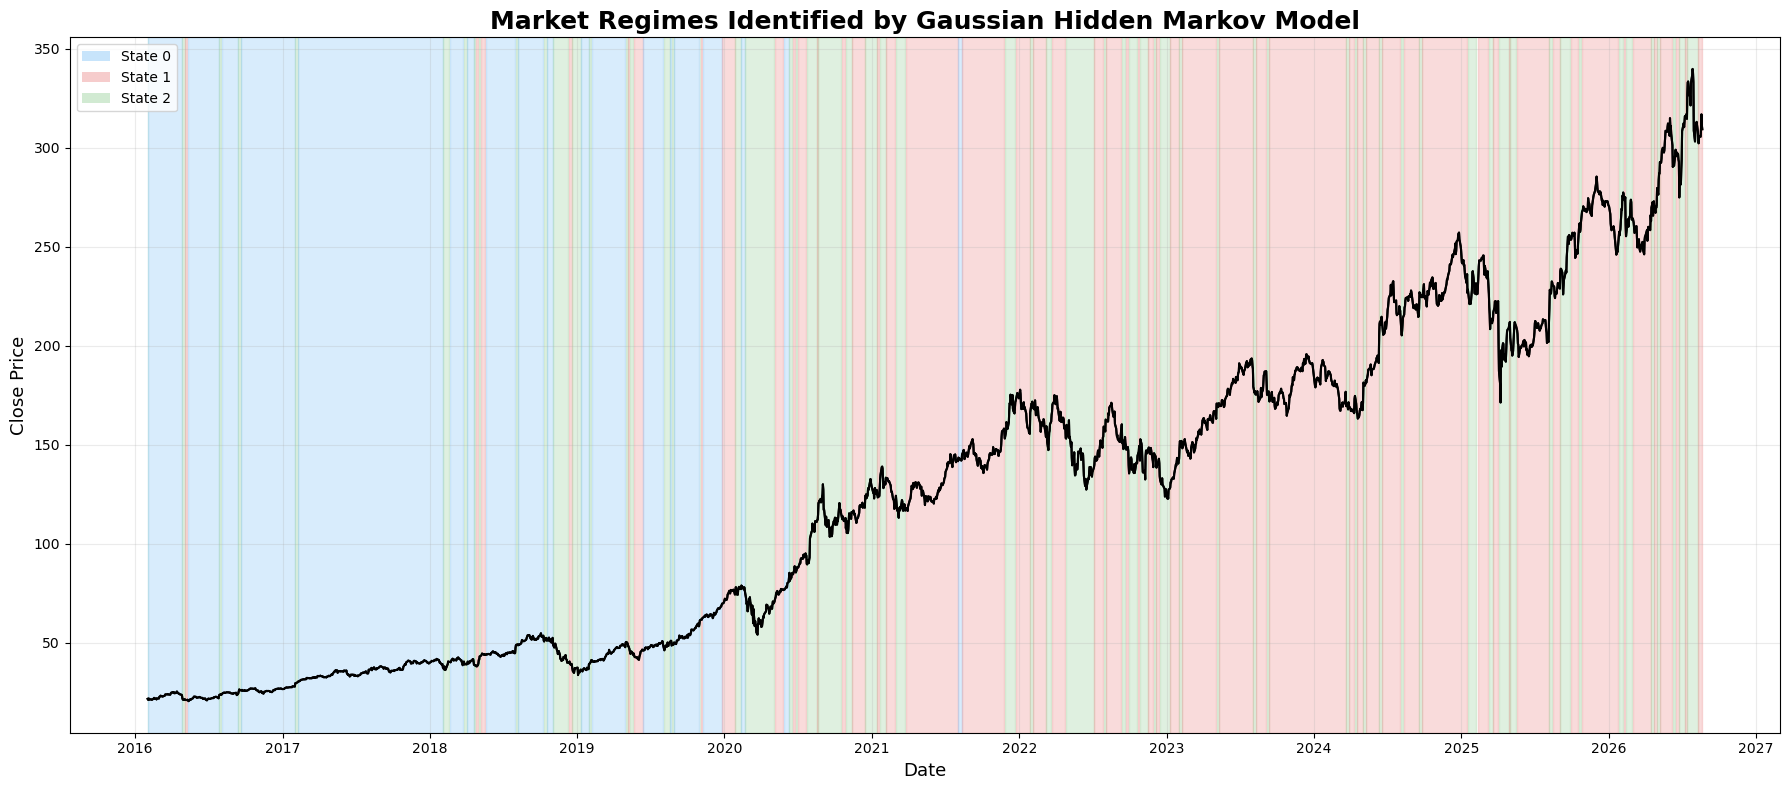

In [11]:
# Chapter 6
# Market Regime Visualization


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Step 1
# Define colors

state_colors = {
    0: "#90CAF9",   # Light Blue
    1: "#EF9A9A",   # Light Red
    2: "#A5D6A7"    # Light Green
}

# Step 2
# Calculate average characteristics of each state

state_summary = data.groupby("State").agg({

    "LogReturn":"mean",

    "Volatility":"mean",

    "Momentum":"mean",

    "MAGap":"mean"

})

print("="*50)
print("State Summary")
print("="*50)

print(state_summary)

# Step 3
# Give every state a temporary name

state_names = {}

for state in state_summary.index:

    state_names[state] = f"State {state}"

# Step 4
# Create Figure

fig, ax = plt.subplots(figsize=(18,8))

# Step 5
# Draw stock price

ax.plot(

    data.index,

    data["Close"],

    color="black",

    linewidth=1.5,

    label="Close Price"

)

# Step 6
# Detect regime changes

regime_groups = (

    data["State"]

    != data["State"].shift()

).cumsum()

# Step 7
# Color every regime

for _, regime in data.groupby(regime_groups):

    current_state = regime["State"].iloc[0]

    ax.axvspan(

        regime.index[0],

        regime.index[-1],

        color=state_colors[current_state],

        alpha=0.35

    )

# Step 8
# Draw price again
# (keep black line on top)

ax.plot(

    data.index,

    data["Close"],

    color="black",

    linewidth=1.5

)

# Step 9
# Format X axis

ax.xaxis.set_major_locator(

    mdates.YearLocator()

)

ax.xaxis.set_major_formatter(

    mdates.DateFormatter("%Y")

)

# Step 10
# Labels

plt.title(

    "Market Regimes Identified by Gaussian Hidden Markov Model",

    fontsize=18,

    weight="bold"

)

plt.xlabel(

    "Date",

    fontsize=13

)

plt.ylabel(

    "Close Price",

    fontsize=13

)

# Step 11
# Legend

legend_elements = []

for state in state_summary.index:

    legend_elements.append(

        Patch(

            facecolor=state_colors[state],

            alpha=0.5,

            label=state_names[state]

        )

    )

plt.legend(

    handles=legend_elements,

    loc="upper left"

)

# Step 12
# Beautify

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [12]:
print(type(data))

print(data.columns)

print(data.head())

print(data.index)

<class 'pandas.core.frame.DataFrame'>
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'LogReturn',
       'Volatility', 'Momentum', 'MA20', 'MAGap', 'State'],
      dtype='object', name='Price')
Price           Close       High        Low       Open     Volume    Return  \
Date                                                                          
2016-02-01  21.682953  21.745913  21.451351  21.691947  163774000 -0.009349   
2016-02-02  21.244480  21.595256  21.199508  21.455844  149428800 -0.020222   
2016-02-03  21.664963  21.775142  21.154538  21.361406  183857200  0.019793   
2016-02-04  21.839039  22.004076  21.520271  21.671742  185886800  0.008035   
2016-02-05  21.255760  21.911384  21.181156  21.820953  185672400 -0.026708   

Price       LogReturn  Volatility  Momentum       MA20     MAGap  State  
Date                                                                     
2016-02-01  -0.009392    0.037166 -0.676811  22.109952 -0.426999      2  
2016-02-02  -0.020

# Chapter 7 Hidden State Statistical Analysis

# Automatic Interpretation Methodology


## How the automatic standards are obtained

The standards have two foundations.

First, they use the normal financial interpretation of the four features:

- Mean Log Return describes average price direction;
- Volatility describes fluctuation and risk;
- Momentum describes recent directional persistence;
- MA Gap describes whether price is above or below its moving average.

Second, the cut-off values are calculated adaptively from the current
three-State results. This prevents a tiny positive or negative number from
being treated automatically as a strong directional signal.

The coefficients `0.25`, `0.85`, and `1.15` are design choices made
for a simple and reproducible interpretation:

- `0.25` creates a small neutral zone;
- `0.85` and `1.15` require volatility to differ from the median by
  approximately 15 percent before it is called low or high.

They are not universal market definitions. The resulting labels should be
described as rule-based summaries of the fitted State statistics.

The HMM discovers the numerical hidden States. The financial names are
generated afterwards from the original-scale State averages.

For Mean Return, Momentum and MA Gap, the function first creates a neutral
zone. A value inside that zone is treated as close to zero.

$$
\epsilon_r
=
\max\left(
0.25\times
\operatorname{median}\left(|\bar{r}_i|\right),
10^{-5}
\right)
$$

$$
\epsilon_m
=
\max\left(
0.25\times
\operatorname{median}\left(|\bar{M}_i|\right),
10^{-8}
\right)
$$

$$
\epsilon_g
=
\max\left(
0.25\times
\operatorname{median}\left(|\bar{G}_i|\right),
10^{-8}
\right)
$$

Volatility is always non-negative, so it is interpreted through relative
comparison with the median State volatility.

$$
\widetilde{\sigma}
=
\operatorname{median}\left(\bar{\sigma}_i\right)
$$

A State is classified as low-volatility below
`0.85median_volatility`, high-volatility above
`1.15median_volatility`, and moderate otherwise.

These coefficients are transparent modelling choices. They are not
estimated by the HMM and they are not universal financial laws.

---

##  7.1 Objective

The objective of this chapter is to analyse the statistical characteristics of the hidden states identified by the Gaussian HMM.

After model estimation, each trading day is assigned an estimated hidden state:

$$
S_t^*
\in
\{0,1,2\}
$$

However, the numerical state labels do not have predefined economic meanings.

Therefore, the characteristics of each state are analysed using:

- Mean Log Return
- Mean Volatility
- Mean Momentum
- Mean Moving Average Gap

The purpose is to understand the statistical behaviour represented by each hidden state.

---

##  7.2 State-Conditional Feature Mean

For a financial feature \(X\), the empirical mean of State \(i\) can be calculated as:

$$
\bar{X}_i
=
\frac{1}{N_i}
\sum_{t:S_t^*=i}
X_t
$$

where:

- \(N_i\) is the number of observations assigned to State \(i\);
- \(S_t^*=i\) means that observation \(t\) is assigned to State \(i\).

For example, the mean Log Return of State \(i\) is:

$$
\bar{r}_i
=
\frac{1}{N_i}
\sum_{t:S_t^*=i}
r_t
$$

The same method can be used for Volatility, Momentum, and MA Gap.

---

##  7.3 State Characteristic Vector

The empirical characteristics of State \(i\) can be summarized as:

$$
C_i
=
\begin{bmatrix}
\bar{r}_i\\
\bar{\sigma}_i\\
\bar{M}_i\\
\bar{G}_i
\end{bmatrix}
$$

where:

- \(\bar{r}_i\): average Log Return;
- \(\bar{\sigma}_i\): average Volatility;
- \(\bar{M}_i\): average Momentum;
- \(\bar{G}_i\): average Moving Average Gap.

Therefore, the three-state model produces three characteristic vectors:

$$
C_0,\qquad C_1,\qquad C_2
$$

These vectors are compared to understand how the hidden regimes differ from one another.

---

##  7.4 Return Interpretation

The average Log Return describes the average direction of price movement within a state.

For State \(i\):

$$
\bar{r}_i
=
E[r_t\mid S_t=i]
$$

A relatively larger value of:

$$
\bar{r}_i
$$

indicates that the state is associated with stronger average returns relative to the other identified states.

A relatively smaller value indicates weaker average return performance.

### Important Note

The interpretation should be **relative to the empirical results**.

For example, it is possible that:

$$
\bar{r}_0>0,\qquad
\bar{r}_1>0,\qquad
\bar{r}_2>0
$$

In this situation, the states still differ in their return levels:

$$
\bar{r}_{low}
<
\bar{r}_{medium}
<
\bar{r}_{high}
$$

Therefore, a state should not automatically be called a bear market simply because it has the lowest mean return among the three states.

---

##  7.5 Volatility Interpretation

The average Volatility of State \(i\) is:

$$
\bar{\sigma}_i
=
E[\sigma_t\mid S_t=i]
$$

A relatively high value indicates:

- stronger price fluctuations;
- greater uncertainty;
- higher market risk.

A relatively low value indicates:

- more stable price behaviour;
- lower short-term fluctuation intensity.

The volatility comparison can be expressed as:

$$
\bar{\sigma}_{low}
<
\bar{\sigma}_{medium}
<
\bar{\sigma}_{high}
$$

The interpretation is based on relative differences between the estimated states.

---

##  7.6 Momentum Interpretation

The average Momentum of State \(i\) is:

$$
\bar{M}_i
=
E[M_t\mid S_t=i]
$$

If:

$$
\bar{M}_i>0
$$

the state is generally associated with positive recent price movement.

If:

$$
\bar{M}_i<0
$$

the state is generally associated with negative recent price movement.

The magnitude of Momentum indicates the strength of recent price movement.

---

##  7.7 Moving Average Gap Interpretation

The average Moving Average Gap of State \(i\) is:

$$
\bar{G}_i
=
E[G_t\mid S_t=i]
$$

where:

$$
G_t=P_t-MA_t
$$

If:

$$
\bar{G}_i>0
$$

prices are generally above the moving average during that state.

If:

$$
\bar{G}_i<0
$$

prices are generally below the moving average during that state.

Therefore, MA Gap provides information about the relationship between the current price and its recent trend.

---

## 7.8 Adaptive Interpretation

The automatic function calculates neutral thresholds from the current state statistics. Therefore, it does not depend on one fixed threshold for every stock and sample period.

The directional evidence score is:

$$
Score_i
=
2D(\bar r_i)
+D(\bar M_i)
+D(\bar G_i)
$$

where Mean Log Return receives weight 2, while Momentum and MA Gap each receive weight 1.

The function can distinguish:

- strong or moderate upward states;
- high-volatility upward states;
- weak upward states with conflicting trend signals;
- strong, stable or moderate downward states;
- downward states with recovery signs;
- stable or volatile sideways states;
- sideways states with upward or downward bias.


If all three Mean Returns are positive, the states can still be separated by Volatility, Momentum and MA Gap.

If two or three Mean Returns are negative, the function distinguishes the strength and stability of the decline and checks whether Momentum and MA Gap show recovery signs.

If Mean Return is close to zero, the state is interpreted as sideways, volatile sideways, or sideways with an upward or downward bias.

The automatic interpretation is a rule-based explanation layer added after HMM training.

The HMM discovers the statistical states. The function only converts the resulting statistics into readable financial descriptions. The generated labels do not prove that a formal bull or bear market exists.

---

##  7.9 State Interpretation Workflow

The state interpretation process is:

**Step 1 — Train Gaussian HMM**

↓

**Step 2 — Obtain Hidden State Sequence**

$$
S_1^*,S_2^*,\ldots,S_T^*
$$

↓

**Step 3 — Group Observations by State**

$$
S_t^*=0,\qquad
S_t^*=1,\qquad
S_t^*=2
$$

↓

**Step 4 — Calculate State Statistics**

$$
C_i
=
\begin{bmatrix}
\bar{r}_i\\
\bar{\sigma}_i\\
\bar{M}_i\\
\bar{G}_i
\end{bmatrix}
$$

↓

**Step 5 — Compare State Characteristics**

↓

**Step 6 — Provide Economic Interpretation**

---

##  7.10 Interpretation Principle

The correct interpretation process is:

$$
\boxed{
\text{Model Estimation}
\rightarrow
\text{State Statistics}
\rightarrow
\text{Relative Comparison}
\rightarrow
\text{Economic Interpretation}
}
$$

The incorrect approach would be:

$$
\text{Predefined Economic Labels}
\rightarrow
\text{Force States into Labels}
$$

The data-driven approach is more appropriate because HMM states are latent statistical regimes discovered from the observed data.

---

##  7.11 Chapter Summary

This chapter analyses the statistical characteristics of the three hidden states.

Each state is described using:

$$
C_i
=
\begin{bmatrix}
Mean\ LogReturn\\
Mean\ Volatility\\
Mean\ Momentum\\
Mean\ MAGap
\end{bmatrix}
$$

The states are interpreted through relative comparison rather than predefined economic labels.

This provides the empirical foundation for understanding the market regimes discovered by the Gaussian HMM.

In [13]:
# Chapter 7
# Hidden State Statistical Analysis and Automatic Interpretation

import numpy as np
import pandas as pd

print("=" * 90)
print("Hidden State Statistical Analysis and Automatic Interpretation")
print("=" * 90)

# Step 1: calculate statistics in original financial units
state_statistics = data.groupby("State").agg({
    "LogReturn": "mean",
    "Volatility": "mean",
    "Momentum": "mean",
    "MAGap": "mean"
})

state_statistics = state_statistics.rename(columns={
    "LogReturn": "Mean Return",
    "Volatility": "Mean Volatility",
    "Momentum": "Mean Momentum",
    "MAGap": "Mean MA Gap"
})

state_statistics["Days"] = data["State"].value_counts().sort_index()
state_statistics["Percentage"] = (
    state_statistics["Days"] / len(data) * 100
)


def directional_sign(value, threshold):
    """Return 1 for positive, 0 for neutral, and -1 for negative."""
    if value > threshold:
        return 1
    if value < -threshold:
        return -1
    return 0


def automatically_interpret_states(statistics):
    """Automatically interpret all hidden states from four state statistics."""

    required_columns = [
        "Mean Return",
        "Mean Volatility",
        "Mean Momentum",
        "Mean MA Gap"
    ]

    missing = [c for c in required_columns if c not in statistics.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Adaptive neutral thresholds
    return_scale = np.nanmedian(np.abs(statistics["Mean Return"]))
    momentum_scale = np.nanmedian(np.abs(statistics["Mean Momentum"]))
    magap_scale = np.nanmedian(np.abs(statistics["Mean MA Gap"]))

    return_threshold = max(0.25 * return_scale, 1e-5)
    momentum_threshold = max(0.25 * momentum_scale, 1e-8)
    magap_threshold = max(0.25 * magap_scale, 1e-8)

    median_volatility = np.nanmedian(statistics["Mean Volatility"])
    low_volatility_threshold = 0.85 * median_volatility
    high_volatility_threshold = 1.15 * median_volatility

    highest_return_state = statistics["Mean Return"].idxmax()
    lowest_return_state = statistics["Mean Return"].idxmin()

    labels = {}
    explanations = {}

    for state, row in statistics.iterrows():
        mean_return = float(row["Mean Return"])
        mean_volatility = float(row["Mean Volatility"])
        mean_momentum = float(row["Mean Momentum"])
        mean_magap = float(row["Mean MA Gap"])

        return_direction = directional_sign(mean_return, return_threshold)
        momentum_direction = directional_sign(mean_momentum, momentum_threshold)
        magap_direction = directional_sign(mean_magap, magap_threshold)

        direction_score = (
            2 * return_direction
            + momentum_direction
            + magap_direction
        )

        if mean_volatility > high_volatility_threshold:
            volatility_level = "high"
        elif mean_volatility < low_volatility_threshold:
            volatility_level = "low"
        else:
            volatility_level = "moderate"

        # Positive-return cases
        if return_direction == 1:
            if (
                direction_score >= 4
                and volatility_level == "low"
                and state == highest_return_state
            ):
                label = "Strong Stable Upward Regime"
            elif direction_score >= 3 and volatility_level == "high":
                label = "High-Volatility Upward Regime"
            elif direction_score >= 3:
                label = "Moderate Upward Regime"
            elif direction_score >= 1:
                label = "Weak Upward Regime"
            else:
                label = "Upward Return with Weakening Trend"

        # Negative-return cases
        elif return_direction == -1:
            if (
                direction_score <= -4
                and volatility_level == "high"
                and state == lowest_return_state
            ):
                label = "Strong High-Volatility Downward Regime"
            elif direction_score <= -4 and state == lowest_return_state:
                label = "Strong Downward Regime"
            elif direction_score <= -3 and volatility_level == "low":
                label = "Stable Downward Regime"
            elif direction_score <= -3:
                label = "Moderate Downward Regime"
            elif direction_score <= -1:
                label = "Weak Downward Regime"
            else:
                label = "Downward Return with Recovery Signs"

        # Near-zero-return cases
        else:
            supporting_score = momentum_direction + magap_direction

            if volatility_level == "high" and supporting_score == 0:
                label = "Volatile Sideways Regime"
            elif volatility_level == "low" and supporting_score == 0:
                label = "Stable Sideways Regime"
            elif supporting_score > 0:
                label = "Sideways Regime with Upward Bias"
            elif supporting_score < 0:
                label = "Sideways Regime with Downward Bias"
            else:
                label = "Sideways Regime"

        if return_direction == 1:
            return_text = "the Mean Return is clearly positive"
        elif return_direction == -1:
            return_text = "the Mean Return is clearly negative"
        else:
            return_text = "the Mean Return is close to zero"

        if momentum_direction == 1:
            momentum_text = "Momentum supports an upward direction"
        elif momentum_direction == -1:
            momentum_text = "Momentum supports a downward direction"
        else:
            momentum_text = "Momentum has no strong direction"

        if magap_direction == 1:
            magap_text = "the price is generally above its moving average"
        elif magap_direction == -1:
            magap_text = "the price is generally below its moving average"
        else:
            magap_text = "the price is close to its moving average"

        explanation = (
            f"State {int(state)} is interpreted as '{label}' because "
            f"{return_text}, Volatility is {volatility_level}, "
            f"{momentum_text}, and {magap_text}."
        )

        labels[int(state)] = label
        explanations[int(state)] = explanation

    thresholds = {
        "Return Neutral Threshold": return_threshold,
        "Momentum Neutral Threshold": momentum_threshold,
        "MA Gap Neutral Threshold": magap_threshold,
        "Low Volatility Threshold": low_volatility_threshold,
        "High Volatility Threshold": high_volatility_threshold
    }

    return labels, explanations, thresholds


# Step 2: run automatic interpretation
(
    state_labels,
    state_explanations,
    interpretation_thresholds
) = automatically_interpret_states(state_statistics)

state_statistics["Regime"] = pd.Series(state_labels)
data["Regime"] = data["State"].map(state_labels)

# Step 3: display results
display_statistics = state_statistics.copy()
display_statistics["Percentage"] = display_statistics["Percentage"].round(2)
display_statistics["Mean Return"] = display_statistics["Mean Return"].round(6)
display_statistics["Mean Volatility"] = display_statistics["Mean Volatility"].round(6)
display_statistics["Mean Momentum"] = display_statistics["Mean Momentum"].round(3)
display_statistics["Mean MA Gap"] = display_statistics["Mean MA Gap"].round(3)

print("\nState Statistics")
print(display_statistics)

print("\n" + "=" * 90)
print("Adaptive Interpretation Thresholds")
print("=" * 90)
for name, value in interpretation_thresholds.items():
    print(f"{name}: {value:.6f}")

print("\n" + "=" * 90)
print("Automatic State Interpretation")
print("=" * 90)
for state in sorted(state_labels):
    print(f"\nState {state}: {state_labels[state]}")
    print(state_explanations[state])

# Step 4: save results
state_statistics.to_csv(
    "state_statistics_with_automatic_labels.csv"
)

explanation_table = pd.DataFrame({
    "State": sorted(state_labels),
    "Regime": [state_labels[s] for s in sorted(state_labels)],
    "Explanation": [state_explanations[s] for s in sorted(state_labels)]
})

explanation_table.to_csv(
    "automatic_state_explanations.csv",
    index=False
)

print("\nState statistics and explanations saved successfully.")

Hidden State Statistical Analysis and Automatic Interpretation

State Statistics
Price  Mean Return  Mean Volatility  Mean Momentum  Mean MA Gap  Days  \
State                                                                   
0         0.001438         0.010239          0.352        0.731   831   
1         0.000689         0.011660          0.666        1.834  1162   
2         0.000987         0.027853          0.570       -0.009   662   

Price  Percentage                         Regime  
State                                             
0           31.30         Moderate Upward Regime  
1           43.77         Moderate Upward Regime  
2           24.93  High-Volatility Upward Regime  

Adaptive Interpretation Thresholds
Return Neutral Threshold: 0.000247
Momentum Neutral Threshold: 0.142598
MA Gap Neutral Threshold: 0.182835
Low Volatility Threshold: 0.009911
High Volatility Threshold: 0.013408

Automatic State Interpretation

State 0: Moderate Upward Regime
State 0 is interpre

# Chapter 8 Transition Matrix Analysis

---

##  8.1 Objective

The objective of this chapter is to analyse how the hidden market states transition over time.

After training, the Gaussian HMM estimates a transition matrix:

$$
A=[a_{ij}]
$$

The transition matrix describes:

1. the probability that a state remains unchanged;
2. the probability of switching between different states;
3. the persistence of each hidden regime.

---

##  8.2 Transition Probability Definition

The transition probability is defined as:

$$
a_{ij}
=
P(S_{t+1}=j\mid S_t=i)
$$

where:

- \(i\) represents the current state;
- \(j\) represents the next state.

For a three-state model:

$$
A=
\begin{bmatrix}
a_{00} & a_{01} & a_{02}\\
a_{10} & a_{11} & a_{12}\\
a_{20} & a_{21} & a_{22}
\end{bmatrix}
$$

Each row represents the probability distribution of the next state conditional on the current state.

---

##  8.3 Probability Constraint

For each current state \(i\), the probabilities of all possible next states must sum to one:

$$
\sum_{j=0}^{N-1}a_{ij}=1
$$

For the three-state model:

$$
a_{i0}+a_{i1}+a_{i2}=1
$$

Therefore, every row of the transition matrix represents a valid probability distribution.

---

##  8.4 Self-Transition Probability

The diagonal elements of the transition matrix are:

$$
a_{00},\qquad
a_{11},\qquad
a_{22}
$$

These values represent the probability that the market remains in the same hidden state.

For State \(i\):

$$
P(S_{t+1}=i\mid S_t=i)
=
a_{ii}
$$

A relatively large value of:

$$
a_{ii}
$$

indicates strong state persistence.

A relatively small value indicates that the state changes more frequently.

---

##  8.5 Transition Matrix Example

Consider the following example:

$$
A=
\begin{bmatrix}
0.90 & 0.08 & 0.02\\
0.10 & 0.80 & 0.10\\
0.03 & 0.07 & 0.90
\end{bmatrix}
$$

For State 0:

$$
P(S_{t+1}=0\mid S_t=0)=0.90
$$

$$
P(S_{t+1}=1\mid S_t=0)=0.08
$$

$$
P(S_{t+1}=2\mid S_t=0)=0.02
$$

Therefore, if the current state is State 0, the model estimates a 90% probability of remaining in State 0 for the next period.

This matrix is only an illustrative example.

The actual transition matrix is estimated from the experimental data.

---

##  8.6 State Persistence

Market regimes often exhibit persistence.

This means:

$$
P(S_{t+1}=i\mid S_t=i)
$$

may be larger than:

$$
P(S_{t+1}=j\mid S_t=i),
\qquad i\neq j
$$

If the diagonal elements dominate the transition matrix:

$$
a_{ii}\gg a_{ij}
$$

the estimated regimes tend to persist over multiple observations.

This is an important reason why HMM is useful for regime analysis.

---

##  8.7 Expected State Duration

Under the standard Markov-chain assumption, the duration of State \(i\) follows a geometric distribution.

If the self-transition probability is:

$$
a_{ii}
$$

then the theoretical expected duration of State \(i\) is:

$$
E[D_i]
=
\frac{1}{1-a_{ii}}
$$

For example, if:

$$
a_{ii}=0.90
$$

then:

$$
E[D_i]
=
\frac{1}{1-0.90}
=
10
$$

This means the theoretical expected duration is approximately 10 time steps.

### Important Note

This theoretical duration is different from the empirical average duration calculated directly from the decoded state sequence.

Theoretical duration:

$$
E[D_i]
=
\frac{1}{1-a_{ii}}
$$

Empirical duration:

$$
\bar{D}_i
=
\frac{1}{K_i}
\sum_{k=1}^{K_i}D_{i,k}
$$

Both measures can be used to analyse state persistence from different perspectives.

---

##  8.8 Most Likely Next State

Given the current State \(i\), the most likely next state is:

$$
\hat{S}_{t+1}
=
\arg\max_j a_{ij}
$$

This means selecting the state with the largest transition probability from the current state.

For example:

$$
A_{i,:}
=
\begin{bmatrix}
0.10 & 0.20 & 0.70
\end{bmatrix}
$$

then:

$$
\hat{S}_{t+1}=2
$$

with confidence:

$$
0.70
$$

---

##  8.9 Transition Matrix Heatmap

The transition matrix can be visualized as a heatmap.

Each cell represents:

$$
a_{ij}
=
P(S_{t+1}=j\mid S_t=i)
$$

The horizontal axis represents:

$$
\text{Next State}
$$

The vertical axis represents:

$$
\text{Current State}
$$

Higher values indicate stronger transition relationships between the corresponding states.

---

##  8.10 Transition Analysis Workflow

The transition analysis process is:

**Step 1 — Obtain Estimated Transition Matrix**

$$
A=model.transmat\_
$$

↓

**Step 2 — Analyse Diagonal Probabilities**

$$
a_{00},\qquad
a_{11},\qquad
a_{22}
$$

↓

**Step 3 — Analyse Cross-State Transitions**

$$
a_{ij},
\qquad i\neq j
$$

↓

**Step 4 — Identify Most Likely Next State**

$$
\hat{S}_{t+1}
=
\arg\max_j a_{ij}
$$

↓

**Step 5 — Visualize Transition Matrix**

---

##  8.11 Interpretation

The transition matrix describes the dynamic structure of the hidden state process.

The key questions are:

- Which states are highly persistent?
- Which states change frequently?
- Which transitions are common?
- Which transitions are rare?

The transition matrix therefore connects:

$$
\boxed{
\text{State Identification}
\rightarrow
\text{Dynamic Analysis}
\rightarrow
\text{State Forecasting}
}
$$

---

##  8.12 Chapter Summary

This chapter analyses the estimated state transition matrix:

$$
A=[a_{ij}]
$$

where:

$$
a_{ij}
=
P(S_{t+1}=j\mid S_t=i)
$$

The diagonal probabilities measure state persistence, while the off-diagonal probabilities describe regime switching.

The transition matrix provides the mathematical foundation for the one-step forecasting method introduced in the next chapter.

Transition Matrix
                 Next State 0  Next State 1  Next State 2
Current State 0        0.9766        0.0032        0.0202
Current State 1        0.0072        0.9475        0.0453
Current State 2        0.0163        0.0866        0.8972

Transition matrix has been saved successfully.

Self-transition Probability
State 0 -> State 0: 0.9766
State 1 -> State 1: 0.9475
State 2 -> State 2: 0.8972

Most Likely Next State
Current State 0  --->  Next State 0    Probability = 0.9766
Current State 1  --->  Next State 1    Probability = 0.9475
Current State 2  --->  Next State 2    Probability = 0.8972


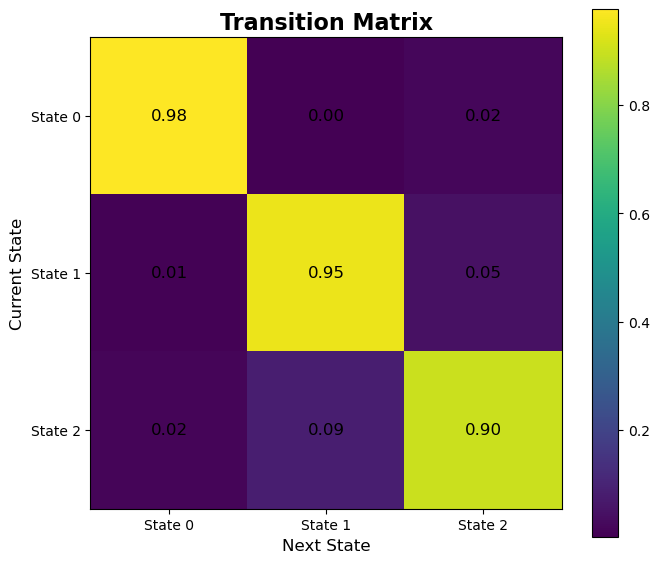


Interpretation
State 0: Very Stable Market Regime (Self-transition = 97.66%)
State 1: Very Stable Market Regime (Self-transition = 94.75%)
State 2: Very Stable Market Regime (Self-transition = 89.72%)


In [14]:
# Chapter 8
# Transition Matrix Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1
# Obtain the Transition Matrix from the trained HMM

transition_matrix = model.transmat_

# Convert to DataFrame for better readability
transition_df = pd.DataFrame(

    transition_matrix,

    index=[f"Current State {i}" for i in range(N_STATES)],

    columns=[f"Next State {i}" for i in range(N_STATES)]

)

print("=" * 70)
print("Transition Matrix")
print("=" * 70)
print(transition_df.round(4))

# Step 2
# Save Transition Matrix

transition_df.to_csv("transition_matrix.csv")

print("\nTransition matrix has been saved successfully.")

# Step 3
# Calculate Self-transition Probability

print("\n" + "=" * 70)
print("Self-transition Probability")
print("=" * 70)

self_transition = np.diag(transition_matrix)

for i in range(N_STATES):

    print(

        f"State {i} -> State {i}: {self_transition[i]:.4f}"

    )

# Step 4
# Find the Most Likely Next State

print("\n" + "=" * 70)
print("Most Likely Next State")
print("=" * 70)

most_likely = np.argmax(

    transition_matrix,

    axis=1

)

for i in range(N_STATES):

    probability = transition_matrix[i, most_likely[i]]

    print(

        f"Current State {i}"

        f"  --->  "

        f"Next State {most_likely[i]}"

        f"    "

        f"Probability = {probability:.4f}"

    )

# Step 5
# Plot Transition Matrix Heatmap

fig, ax = plt.subplots(

    figsize=(7,6)

)

image = ax.imshow(

    transition_matrix,

    interpolation="nearest"

)

# Axis labels

ax.set_xticks(range(N_STATES))

ax.set_yticks(range(N_STATES))

ax.set_xticklabels(

    [f"State {i}" for i in range(N_STATES)]

)

ax.set_yticklabels(

    [f"State {i}" for i in range(N_STATES)]

)

plt.xlabel(

    "Next State",

    fontsize=12

)

plt.ylabel(

    "Current State",

    fontsize=12

)

plt.title(

    "Transition Matrix",

    fontsize=16,

    fontweight="bold"

)

# Step 6
# Display probability inside each cell

for i in range(N_STATES):

    for j in range(N_STATES):

        ax.text(

            j,

            i,

            f"{transition_matrix[i,j]:.2f}",

            ha="center",

            va="center",

            fontsize=12

        )

# Step 7
# Add color bar

plt.colorbar(image)

plt.tight_layout()

plt.show()

# Step 8
# Interpretation

print("\n" + "=" * 70)
print("Interpretation")
print("=" * 70)

for i in range(N_STATES):

    if self_transition[i] > 0.85:

        print(

            f"State {i}: "

            f"Very Stable Market Regime "

            f"(Self-transition = {self_transition[i]:.2%})"

        )

    elif self_transition[i] > 0.70:

        print(

            f"State {i}: "

            f"Moderately Stable Market Regime "

            f"(Self-transition = {self_transition[i]:.2%})"

        )

    else:

        print(

            f"State {i}: "

            f"Highly Dynamic Market Regime "

            f"(Self-transition = {self_transition[i]:.2%})"

        )

# Chapter 9 Next Market Regime Prediction

---

##  9.1 Objective

The objective of this chapter is to predict and interpret the most likely hidden state for the next trading period.

The model uses the current hidden state, the transition matrix and the automatic state labels generated in Chapter 7. It does not directly predict the exact future stock price.

---

##  9.2 Current Hidden State

After HMM training, each trading day is assigned an estimated hidden state:

$$
S_t^* \in \{0,1,2\}
$$

The current hidden state is taken as the last estimated state in the dataset:

$$
S_t^*
$$

In the Python implementation:

```python
current_state = data["State"].iloc[-1]
```

---

##  9.3 Transition Probability

The transition matrix is defined as:

$$
A=[a_{ij}]
$$

where:

$$
a_{ij}
=
P(S_{t+1}=j \mid S_t=i)
$$

If the current state is \(i\), the next-state probability distribution is the \(i\)-th row of the transition matrix:

$$
p_{t+1}
=
A_{i,:}
=
\begin{bmatrix}
a_{i0} & a_{i1} & a_{i2}
\end{bmatrix}
$$

In the Python implementation:

```python
transition_probability = model.transmat_[current_state]
```

---

##  9.4 Predicted Next State

The predicted next hidden state is selected as the state with the highest transition probability:

$$
\hat{S}_{t+1}
=
\arg\max_j a_{ij}
$$

In the Python implementation:

```python
predicted_state = np.argmax(transition_probability)
```

---

##  9.5 Prediction Confidence

The prediction confidence is defined as the highest probability in the next-state probability distribution:

$$
Confidence
=
\max_j a_{ij}
$$

In the Python implementation:

```python
prediction_confidence = np.max(transition_probability)
```

A higher confidence means that the model assigns a larger probability to the predicted next state.

---

## 9.6 Expected State Characteristics

After the next state is predicted, the model retrieves the mean feature values of the predicted hidden state.

In the Python implementation:

```python
expected_return = model.means_[predicted_state, 0]
expected_volatility = model.means_[predicted_state, 1]
expected_momentum = model.means_[predicted_state, 2]
expected_magap = model.means_[predicted_state, 3]
```

Since the HMM was trained using standardized data:

$$
X_{scaled}
=
\frac{X-\mu_X}{\sigma_X}
$$

the values stored in:

```python
model.means_
```

are also expressed in the standardized feature space.

Therefore, the expected characteristics should be interpreted as standardized state-level feature values, rather than raw financial values.

---

##  9.7 Important Interpretation Note

The values printed as:

- Expected Log Return
- Expected Volatility
- Expected Momentum
- Expected MA Gap

come from the standardized feature space.

Therefore:

$$
model.means_
\neq
\text{raw financial feature means}
$$

Strictly speaking, these values represent the position of the predicted state relative to the standardized feature distribution.

For example:

- a positive standardized return mean means that the predicted state has above-average return relative to the standardized data;
- a positive standardized momentum mean means that the predicted state has above-average momentum relative to the standardized data;
- a positive standardized MA Gap means that the predicted state tends to be above its moving average in standardized terms.

---

##  9.8 Market Direction Rule

The code uses the sign of the standardized expected return to give a simple directional interpretation:

$$
\text{Direction}
=
\begin{cases}
UP, & \text{if } \mu_{return}>0\\
DOWN, & \text{if } \mu_{return}\leq 0
\end{cases}
$$

In the Python implementation:

```python
if expected_return > 0:
    direction = "UP"
else:
    direction = "DOWN"
```

This rule should be interpreted carefully.

It does not mean that the model guarantees the next stock price will increase or decrease.

It only means that the predicted hidden state has a positive or negative standardized return characteristic.

---

##  9.9 One-Step Prediction Algorithm

The complete prediction process is:

**Step 1 — Identify the current hidden state**

$$
S_t^*=i
$$

↓

**Step 2 — Extract next-state probabilities**

$$
p_{t+1}=A_{i,:}
$$

↓

**Step 3 — Select the state with the highest probability**

$$
\hat{S}_{t+1}
=
\arg\max_j a_{ij}
$$

↓

**Step 4 — Calculate prediction confidence**

$$
Confidence
=
\max_j a_{ij}
$$

↓

**Step 5 — Retrieve standardized characteristics of the predicted state**

$$
\mu_{\hat{S}_{t+1}}
$$

↓

**Step 6 — Provide directional interpretation**

---

##  9.10 Interpretation

This chapter performs a one-step hidden state forecast.

The model predicts the most likely next market regime using the transition matrix.

The result should be interpreted as:

> Given the current estimated hidden state, the Gaussian HMM predicts which hidden state is most likely to occur in the next trading period.

It should not be interpreted as a deterministic stock price forecast.

---

##  9.11 Chapter Summary

If the current state is `i`, the probability of moving to State `j` is:

$$
a_{ij}=P(S_{t+1}=j\mid S_t=i)
$$

The core prediction equation is:

$$
\hat{S}_{t+1}
=
\arg\max_j a_{ij}
$$

and the prediction confidence is:

$$
Confidence
=
\max_j a_{ij}
$$

The Chapter 9 prediction module provides:

The expected characteristics are obtained from `state_statistics`, which contains original-scale financial values. This avoids treating standardized values in `model.means_` as original quantities.

The output includes the numerical State, automatic Regime label, confidence, explanation and expected state characteristics.

In [15]:
# Chapter 9
# Next Market Regime Prediction

import numpy as np
import pandas as pd

print("=" * 80)
print("Next Market Regime Prediction")
print("=" * 80)

current_state = int(data["State"].iloc[-1])
current_regime = state_labels[current_state]

print(f"\nCurrent State: State {current_state}")
print(f"Current Regime: {current_regime}")
print(f"Current-State Explanation: {state_explanations[current_state]}")

transition_probability = model.transmat_[current_state]

print("\nTransition Probabilities")
for state in range(N_STATES):
    print(
        f"State {current_state} --> State {state} "
        f"({state_labels[state]}): {transition_probability[state]:.4f}"
    )

predicted_state = int(np.argmax(transition_probability))
prediction_confidence = float(np.max(transition_probability))
predicted_regime = state_labels[predicted_state]
predicted_explanation = state_explanations[predicted_state]

print("\nPredicted Next State")
print(f"State {predicted_state}")
print(f"Predicted Regime: {predicted_regime}")
print(f"Prediction Confidence: {prediction_confidence:.2%}")
print(f"Predicted-State Explanation: {predicted_explanation}")

predicted_profile = state_statistics.loc[predicted_state]
expected_return = float(predicted_profile["Mean Return"])
expected_volatility = float(predicted_profile["Mean Volatility"])
expected_momentum = float(predicted_profile["Mean Momentum"])
expected_magap = float(predicted_profile["Mean MA Gap"])

print("\nExpected Characteristics")
print(f"Expected Log Return: {expected_return:.6f}")
print(f"Expected Volatility: {expected_volatility:.6f}")
print(f"Expected Momentum: {expected_momentum:.3f}")
print(f"Expected MA Gap: {expected_magap:.3f}")

return_threshold = interpretation_thresholds["Return Neutral Threshold"]
if expected_return > return_threshold:
    average_direction = "Positive Average Direction"
elif expected_return < -return_threshold:
    average_direction = "Negative Average Direction"
else:
    average_direction = "Near-Zero Average Direction"

prediction_result = pd.DataFrame({
    "Current State": [current_state],
    "Current Regime": [current_regime],
    "Predicted State": [predicted_state],
    "Predicted Regime": [predicted_regime],
    "Confidence": [prediction_confidence],
    "Expected Log Return": [expected_return],
    "Expected Volatility": [expected_volatility],
    "Expected Momentum": [expected_momentum],
    "Expected MA Gap": [expected_magap],
    "Average Direction": [average_direction],
    "State Explanation": [predicted_explanation]
})

print("\nPrediction Result")
print(prediction_result)

prediction_result.to_csv("next_state_prediction.csv", index=False)
print("\nPrediction saved successfully.")

Next Market Regime Prediction

Current State: State 1
Current Regime: Moderate Upward Regime
Current-State Explanation: State 1 is interpreted as 'Moderate Upward Regime' because the Mean Return is clearly positive, Volatility is moderate, Momentum supports an upward direction, and the price is generally above its moving average.

Transition Probabilities
State 1 --> State 0 (Moderate Upward Regime): 0.0072
State 1 --> State 1 (Moderate Upward Regime): 0.9475
State 1 --> State 2 (High-Volatility Upward Regime): 0.0453

Predicted Next State
State 1
Predicted Regime: Moderate Upward Regime
Prediction Confidence: 94.75%
Predicted-State Explanation: State 1 is interpreted as 'Moderate Upward Regime' because the Mean Return is clearly positive, Volatility is moderate, Momentum supports an upward direction, and the price is generally above its moving average.

Expected Characteristics
Expected Log Return: 0.000689
Expected Volatility: 0.011660
Expected Momentum: 0.666
Expected MA Gap: 1.834


# Chapter 10 Model Evaluation

---

## 10.1 Objective

The objective of this chapter is to evaluate the fitted Gaussian Hidden
Markov Model using three quantitative measures:

- Root Mean Squared Error (RMSE);
- R-squared (\(R^2\));
- Bayesian Information Criterion (BIC).

The HMM used in this project is unsupervised. Therefore, the historical
dataset does not contain observed true market-regime labels against
which ordinary classification accuracy can be calculated.

RMSE and \(R^2\) are therefore used as auxiliary reconstruction measures.
They examine how well the typical observation profile of each decoded
hidden State represents the actual financial observations.

BIC is used separately to compare Gaussian HMMs containing different
numbers of hidden States.

---

## 10.2 State-Mean Reconstruction

The fitted three-State Gaussian HMM learns one Gaussian mean vector for
each hidden State:

$$
\mu_0,\quad \mu_1,\quad \mu_2.
$$

Each mean vector contains four values corresponding to the four
standardised HMM features:

$$
X_t
=
\begin{bmatrix}
LogReturn_t \\
Volatility_t \\
Momentum_t \\
MAGap_t
\end{bmatrix}.
$$

Here:

- \(t\) represents one trading day;
- \(X_t\) is the four-dimensional observation for trading day \(t\);
- \(\mu_i\) is the Gaussian mean vector learned for hidden State \(i\).

After the HMM parameters have been trained, the Viterbi algorithm assigns
each historical observation to one most likely hidden State.

Let

$$
S_t^*
$$

represent the Viterbi-decoded State at trading day \(t\).

A State-based reconstructed observation is defined as:

$$
\hat{X}_t
=
\mu_{S_t^*}.
$$

For example, if:

$$
S_t^*=2,
$$

then the Gaussian mean vector of State 2 is used as the representative
value for that trading day.

The comparison is therefore between:

$$
X_t
\quad\text{and}\quad
\hat{X}_t.
$$

This does not mean that the HMM predicts the exact observation.
Instead, it measures how well the statistical profile of the decoded
State represents the actual observation.

---

## 10.3 Root Mean Squared Error

The Root Mean Squared Error measures the average difference between the
actual observations and the State-based reconstructed observations.

For one variable:

$$
RMSE
=
\sqrt{
\frac{1}{T}
\sum_{t=1}^{T}
(x_t-\hat{x}_t)^2
},
$$

where:

- \(T\) is the total number of observations;
- \(x_t\) is the actual observed value;
- \(\hat{x}_t\) is the reconstructed value from the decoded State.

A smaller RMSE indicates that the State-based representative values are
closer to the observed data.

Therefore:

$$
\text{Lower RMSE}
\Rightarrow
\text{Smaller Reconstruction Error}.
$$

The four HMM variables have different numerical units. For example,
Log Return is measured on a much smaller numerical scale than Momentum
or MA Gap.

For this reason, the overall RMSE is calculated using the standardised
feature matrix.

Feature-level RMSE values are also reported in their original financial
units for additional interpretation.

RMSE is used as an auxiliary reconstruction measure rather than a
supervised prediction-accuracy measure.

---

## 10.4 R-squared

The coefficient of determination, \(R^2\), measures how much of the
variation in the observations is represented by the State-based
reconstruction.

For one variable:

$$
R^2
=
1-
\frac{
\sum_{t=1}^{T}
(x_t-\hat{x}_t)^2
}{
\sum_{t=1}^{T}
(x_t-\bar{x})^2
},
$$

where:

- \(x_t\) is the actual observed value;
- \(\hat{x}_t\) is the State-based reconstructed value;
- \(\bar{x}\) is the overall sample mean of the variable.

The numerator:

$$
\sum_{t=1}^{T}(x_t-\hat{x}_t)^2
$$

represents the reconstruction error.

The denominator:

$$
\sum_{t=1}^{T}(x_t-\bar{x})^2
$$

represents the total variation in the observed data.

In general, a larger \(R^2\) indicates that the State-based
representation captures more of the variation in the observations.

For example:

$$
R^2=0.60
$$

means that approximately 60\% of the variation is represented under
this reconstruction measure.

A value close to zero indicates limited improvement over using the
overall sample mean.

A negative \(R^2\) is also possible. This does not automatically mean
that the HMM is invalid, because the HMM is trained by maximising
likelihood rather than by minimising squared reconstruction error.

Therefore, \(R^2\), like RMSE, is treated as an auxiliary evaluation
measure.

---

## 10.5 Bayesian Information Criterion

The Bayesian Information Criterion is used to compare HMMs with
different numbers of hidden States.

Let:

$$
\ell
=
\log P(X\mid\hat{\lambda})
$$

represent the log likelihood of the observed sequence under the fitted
HMM.

Here:

- \(X\) is the complete observation sequence;
- \(\hat{\lambda}\) represents the fitted HMM parameters;
- \(\ell\) is the resulting log likelihood.

The BIC is defined as:

$$
BIC
=
-2\ell
+
q\ln(T),
$$

where:

- \(\ell\) is the log likelihood;
- \(q\) is the number of free parameters in the model;
- \(T\) is the number of observations;
- \(\ln(T)\) is the natural logarithm of the sample size.

The first part,

$$
-2\ell,
$$

reflects model fit.

The second part,

$$
q\ln(T),
$$

penalises model complexity.

Therefore, BIC balances two objectives:

$$
\text{Good Model Fit}
\quad+\quad
\text{Reasonable Model Complexity}.
$$

Unlike RMSE and \(R^2\), a BIC value is not interpreted on its own.
It must be compared with BIC values from alternative models fitted to
the same dataset.

In this project, four candidate models are compared:

$$
K\in\{2,3,4,5\},
$$

where \(K\) is the number of hidden States.

The preferred candidate according to BIC is:

$$
K_{\mathrm{BIC}}
=
\arg\min_K BIC(K).
$$

The symbol \(\arg\min\) means the value of \(K\) that produces the
smallest BIC.

Therefore:

$$
\text{Lower BIC}
\Rightarrow
\text{Preferred Candidate Model}.
$$

The two-State, four-State and five-State models are trained only for
this BIC comparison. They do not replace the main three-State HMM used
for State interpretation, transition analysis, and forecasting.

For consistency with the main experiment, all candidate models use the
same four standardised features, full covariance matrices, maximum
iteration setting, and random seed.

---

## 10.6 Evaluation Interpretation

The three measures answer different questions.

### RMSE

RMSE answers:

> How far are the State-based representative observations from the
> actual observations?

A smaller value represents a smaller reconstruction error.

### \(R^2\)

\(R^2\) answers:

> How much of the variation in the observations is represented by the
> State-based reconstruction?

A larger value generally indicates stronger representation.

### BIC

BIC answers:

> How does the selected number of hidden States balance model fit and
> model complexity?

The candidate model with the lowest BIC is preferred according to this
criterion.

These three quantities should not be interpreted as three versions of
the same accuracy measure. They evaluate different statistical aspects
of the Gaussian HMM.

---

## 10.7 Evaluation Limitations

Several limitations should be considered when interpreting these
measures.

First, RMSE and \(R^2\) are not optimisation objectives of the Gaussian
HMM. The HMM is trained by maximising the likelihood of the observation
sequence. Therefore, RMSE and \(R^2\) are used only as auxiliary
reconstruction measures.

Second, BIC provides a relative comparison between the candidate
models considered in this experiment. It does not prove that one model
is universally optimal.

Third, the BIC comparison uses the same fixed random seed as the main
experiment to maintain a simple and reproducible comparison. Because
Baum--Welch estimation can converge to local optima, the comparison
should be interpreted as a model-selection check rather than an
exhaustive search over every possible HMM specification.

Finally, none of these measures represents supervised classification
accuracy because true historical market-regime labels are not available.

---

## 10.8 Chapter Summary

This chapter evaluates the main three-State Gaussian HMM using RMSE and
\(R^2\) as auxiliary State-based reconstruction measures.

The overall RMSE measures the reconstruction error:

$$
RMSE
=
\sqrt{
\frac{1}{T}
\sum_{t=1}^{T}
(x_t-\hat{x}_t)^2
}.
$$

The \(R^2\) measure evaluates the proportion of variation represented by
the reconstruction:

$$
R^2
=
1-
\frac{
\sum_{t=1}^{T}(x_t-\hat{x}_t)^2
}{
\sum_{t=1}^{T}(x_t-\bar{x})^2
}.
$$

BIC is used to compare models containing two, three, four, and five
hidden States:

$$
BIC
=
-2\ell+q\ln(T).
$$

Together, the three measures provide a concise evaluation of
reconstruction quality and model complexity without treating the
unsupervised HMM as a supervised classification model.

In [16]:
# ============================================================
# Chapter 10
# Gaussian HMM Model Evaluation
#
# Evaluation Measures:
# 1. RMSE
# 2. R-squared
# 3. BIC comparison
#
# Main model:
# 3-State Gaussian HMM
#
# Additional 2-State, 4-State and 5-State models
# are trained ONLY for BIC comparison.
# ============================================================


import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from hmmlearn.hmm import GaussianHMM


print("=" * 80)
print("CHAPTER 10 - MODEL EVALUATION")
print("=" * 80)


# ============================================================
# Step 1
# Basic Settings
# ============================================================

FEATURES = [
    "LogReturn",
    "Volatility",
    "Momentum",
    "MAGap"
]

MAIN_N_STATES = 3


# Check whether Viterbi decoding has already been completed

if "State" not in data.columns:

    raise ValueError(
        "State column not found. "
        "Please run the HMM training and Viterbi decoding first."
    )


# Original observations in original financial units

X_original = (
    data[FEATURES]
    .to_numpy()
)


# Viterbi-decoded State sequence
# from the MAIN three-State model

decoded_states = (
    data["State"]
    .astype(int)
    .to_numpy()
)


# Safety check

if len(decoded_states) != len(X_scaled):

    raise ValueError(
        "The State sequence and X_scaled "
        "do not have the same number of observations."
    )


# ============================================================
# Step 2
# State-Mean Reconstruction
# ============================================================

# model.means_ contains one Gaussian mean vector
# for each hidden State.
#
# Because the HMM was fitted using X_scaled,
# these means are also in standardised units.
#
# Example:
#
# If decoded_states[t] == 2,
# the mean vector of State 2 is used to
# represent observation t.


X_reconstructed_scaled = (
    model.means_[decoded_states]
)


# Convert reconstructed observations back
# to original financial units

X_reconstructed_original = (
    scaler.inverse_transform(
        X_reconstructed_scaled
    )
)


print("\nState-mean reconstruction completed.")


# ============================================================
# Step 3
# Feature-Level RMSE and R-squared
# ============================================================

feature_results = []


for feature_index, feature in enumerate(FEATURES):

    actual_values = (
        X_original[:, feature_index]
    )

    reconstructed_values = (
        X_reconstructed_original[
            :,
            feature_index
        ]
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse_value = np.sqrt(
        mean_squared_error(
            actual_values,
            reconstructed_values
        )
    )


    # --------------------------------------------------------
    # R-squared
    # --------------------------------------------------------

    r2_value = r2_score(
        actual_values,
        reconstructed_values
    )


    feature_results.append({

        "Feature": feature,

        "RMSE": rmse_value,

        "R_squared": r2_value

    })


feature_evaluation = pd.DataFrame(
    feature_results
)


print("\n" + "=" * 80)
print("FEATURE-LEVEL RECONSTRUCTION")
print("=" * 80)

print(
    feature_evaluation.round(6)
)


# ============================================================
# Step 4
# Overall Standardised RMSE
# ============================================================

# The four financial features have different units.
#
# Therefore, the OVERALL RMSE is calculated in
# standardised space so that one large-scale feature
# does not dominate the result.


overall_rmse = np.sqrt(
    mean_squared_error(
        X_scaled,
        X_reconstructed_scaled
    )
)


print("\n" + "=" * 80)
print("OVERALL STANDARDISED RMSE")
print("=" * 80)

print(
    f"Overall Standardised RMSE: "
    f"{overall_rmse:.6f}"
)


# ============================================================
# Step 5
# Overall R-squared
# ============================================================

# Calculate R-squared separately for each standardised
# feature and then take their equal-weight average.


overall_r2 = r2_score(
    X_scaled,
    X_reconstructed_scaled,
    multioutput="uniform_average"
)


print("\n" + "=" * 80)
print("OVERALL R-SQUARED")
print("=" * 80)

print(
    f"Overall R-squared: "
    f"{overall_r2:.6f}"
)


# ============================================================
# Step 6
# Summary of RMSE and R-squared
# ============================================================

main_model_summary = pd.DataFrame({

    "Measure": [
        "Overall Standardised RMSE",
        "Overall R-squared"
    ],

    "Value": [
        overall_rmse,
        overall_r2
    ]

})


print("\n" + "=" * 80)
print("MAIN THREE-STATE MODEL SUMMARY")
print("=" * 80)

print(
    main_model_summary.round(6)
)


# ============================================================
# Step 7
# Helper Function for BIC
# ============================================================

def calculate_bic(hmm_model, X_input):

    """
    Calculate BIC for a fitted Gaussian HMM.

    Use hmmlearn's built-in bic() method when available.

    If bic() is unavailable in the installed version,
    calculate BIC manually.
    """

    try:

        bic_value = hmm_model.bic(
            X_input
        )

        return bic_value


    except AttributeError:

        # ----------------------------------------------------
        # Manual BIC calculation
        # ----------------------------------------------------

        K = hmm_model.n_components

        d = X_input.shape[1]

        T = X_input.shape[0]


        # Log Likelihood

        log_likelihood = (
            hmm_model.score(
                X_input
            )
        )


        # ----------------------------------------------------
        # Number of free parameters
        #
        # Full-covariance Gaussian HMM
        # ----------------------------------------------------
        #
        # (K - 1)
        # Initial-state probabilities
        #
        # K(K - 1)
        # Transition probabilities
        #
        # Kd
        # Gaussian means
        #
        # K*d*(d+1)/2
        # Full covariance matrices
        # ----------------------------------------------------

        q = (

            (K - 1)

            + K * (K - 1)

            + K * d

            + K * d * (d + 1) / 2

        )


        bic_value = (

            -2 * log_likelihood

            + q * np.log(T)

        )


        return bic_value


# ============================================================
# Step 8
# BIC Comparison
#
# Compare:
#
# K = 2
# K = 3
# K = 4
# K = 5
#
# The existing main model is reused for K = 3.
#
# Only K = 2, 4 and 5 require additional fitting.
# ============================================================

candidate_states = [
    2,
    3,
    4,
    5
]


bic_results = []


print("\n" + "=" * 80)
print("BIC COMPARISON")
print("=" * 80)


for n_states in candidate_states:


    # --------------------------------------------------------
    # Use existing main model for K = 3
    # --------------------------------------------------------

    if n_states == MAIN_N_STATES:

        comparison_model = model

        print(
            "\nUsing existing "
            "3-State main model..."
        )


    # --------------------------------------------------------
    # Train an additional model for K = 2, 4 or 5
    # --------------------------------------------------------

    else:

        print(
            f"\nTraining "
            f"{n_states}-State Gaussian HMM..."
        )


        comparison_model = GaussianHMM(

            n_components=n_states,

            covariance_type="full",

            n_iter=2000,

            random_state=42

        )


        comparison_model.fit(
            X_scaled
        )


    # --------------------------------------------------------
    # Log Likelihood
    # Used internally for understanding BIC
    # --------------------------------------------------------

    candidate_log_likelihood = (
        comparison_model.score(
            X_scaled
        )
    )


    # --------------------------------------------------------
    # BIC
    # --------------------------------------------------------

    candidate_bic = calculate_bic(

        comparison_model,

        X_scaled

    )


    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    bic_results.append({

        "Number_of_States":
            n_states,

        "Log_Likelihood":
            candidate_log_likelihood,

        "BIC":
            candidate_bic

    })


# ============================================================
# Step 9
# BIC Comparison Table
# ============================================================

bic_comparison = pd.DataFrame(
    bic_results
)


print("\n" + "=" * 80)
print("BIC COMPARISON TABLE")
print("=" * 80)

print(
    bic_comparison.round(4)
)


# ============================================================
# Step 10
# Find Lowest BIC
# ============================================================

best_row_index = (
    bic_comparison[
        "BIC"
    ].idxmin()
)


best_number_of_states = int(

    bic_comparison.loc[
        best_row_index,
        "Number_of_States"
    ]

)


best_bic_value = (

    bic_comparison.loc[
        best_row_index,
        "BIC"
    ]

)


print("\n" + "=" * 80)
print("BIC MODEL-SELECTION RESULT")
print("=" * 80)

print(
    f"Lowest BIC: "
    f"{best_bic_value:.4f}"
)

print(
    f"Preferred number of States "
    f"according to BIC: "
    f"{best_number_of_states}"
)


# ============================================================
# Final Message
# ============================================================

print("\n" + "=" * 80)
print("CHAPTER 10 MODEL EVALUATION COMPLETED")
print("=" * 80)

CHAPTER 10 - MODEL EVALUATION

State-mean reconstruction completed.

FEATURE-LEVEL RECONSTRUCTION
      Feature      RMSE  R_squared
0   LogReturn  0.018136   0.000281
1  Volatility  0.007265   0.501424
2    Momentum  5.841743   0.000340
3       MAGap  6.055298   0.015474

OVERALL STANDARDISED RMSE
Overall Standardised RMSE: 0.933070

OVERALL R-SQUARED
Overall R-squared: 0.129380

MAIN THREE-STATE MODEL SUMMARY
                     Measure    Value
0  Overall Standardised RMSE  0.93307
1          Overall R-squared  0.12938

BIC COMPARISON

Training 2-State Gaussian HMM...

Using existing 3-State main model...

Training 4-State Gaussian HMM...

Training 5-State Gaussian HMM...

BIC COMPARISON TABLE
   Number_of_States  Log_Likelihood         BIC
0                 2     -10806.9702  21858.3505
1                 3      -9612.3411  19618.8923
2                 4      -9051.8557  18663.4896
3                 5      -8511.5130  17764.1408

BIC MODEL-SELECTION RESULT
Lowest BIC: 17764.1408
Pr

# Chapter 11 Multi-step Market Regime Forecasting

---

##  11.1 Objective

The objective of this chapter is to extend the one-step hidden state forecast into a multi-step market regime forecast.

Chapter 9 predicts the hidden state for the next trading period.

Chapter 11 extends the forecasting horizon to:

$$
k=1,2,\ldots,20
$$

trading periods ahead.

The multi-step forecast estimates the probability distribution of the hidden market state at different future horizons.

The main forecasting equation is:

$$
\boxed{
\pi_{t+k}
=
\pi_tA^k
}
$$

where:

- \(\pi_t\) is the current state probability vector;
- \(A\) is the estimated transition matrix;
- \(A^k\) is the \(k\)-step transition matrix;
- \(\pi_{t+k}\) is the predicted state probability distribution \(k\) periods ahead.

---

##  11.2 Current Hidden State

The forecasting process begins with the current estimated hidden state.

Suppose the current state is:

$$
S_t=i
$$

where:

$$
i\in\{0,1,2\}
$$

In the Python implementation, the current state is obtained from the final observation in the decoded state sequence:

```python
current_state = data["State"].iloc[-1]
```

The multi-step forecasting process starts from this estimated current state.

---

##  11.3 Initial Probability Vector

The current hidden state is converted into an initial probability vector.

For a three-state model:

$$
\pi_t
=
\begin{bmatrix}
P(S_t=0) &
P(S_t=1) &
P(S_t=2)
\end{bmatrix}
$$

The current implementation uses a **hard-state assumption**.

This means that the current estimated state is assigned probability 1, while the other states are assigned probability 0.

For example, if:

$$
S_t=0
$$

then:

$$
\pi_t=
\begin{bmatrix}
1&0&0
\end{bmatrix}
$$

If:

$$
S_t=1
$$

then:

$$
\pi_t=
\begin{bmatrix}
0&1&0
\end{bmatrix}
$$

If:

$$
S_t=2
$$

then:

$$
\pi_t=
\begin{bmatrix}
0&0&1
\end{bmatrix}
$$

In the Python implementation:

```python
initial_prob = np.zeros(N_STATES)

initial_prob[current_state] = 1
```

Therefore:

$$
\boxed{
\text{Current State}
\rightarrow
\text{One-Hot Probability Vector}
}
$$

---

##  11.4 One-Step Transition

The transition matrix is:

$$
A=[a_{ij}]
$$

where:

$$
a_{ij}
=
P(S_{t+1}=j\mid S_t=i)
$$

The one-step future state probability distribution is:

$$
\pi_{t+1}
=
\pi_tA
$$

For example, suppose:

$$
\pi_t=
\begin{bmatrix}
0&0&1
\end{bmatrix}
$$

Then:

$$
\pi_{t+1}
=
\begin{bmatrix}
0&0&1
\end{bmatrix}
A
$$

The result is the probability distribution of the hidden state one period ahead.

---

##  11.5 Two-Step Transition

The two-step state probability distribution is:

$$
\pi_{t+2}
=
\pi_tA^2
$$

Since:

$$
A^2=A\times A
$$

the probability of moving from State \(i\) to State \(j\) in two steps is:

$$
(A^2)_{ij}
=
\sum_{m=0}^{N-1}
a_{im}a_{mj}
$$

This formula considers all possible intermediate states \(m\).

For example:

$$
i
\rightarrow
m
\rightarrow
j
$$

Therefore, a two-step forecast includes every possible two-step transition path.

---

##  11.6 General Multi-Step Forecast

For a forecast horizon of \(k\) periods, the transition matrix is raised to the power \(k\):

$$
A^k
$$

The future state probability distribution is:

$$
\boxed{
\pi_{t+k}
=
\pi_tA^k
}
$$

For example:

### One period ahead

$$
\pi_{t+1}
=
\pi_tA
$$

### Five periods ahead

$$
\pi_{t+5}
=
\pi_tA^5
$$

### Ten periods ahead

$$
\pi_{t+10}
=
\pi_tA^{10}
$$

### Twenty periods ahead

$$
\pi_{t+20}
=
\pi_tA^{20}
$$

In the Python implementation:

```python
transition_power = np.linalg.matrix_power(
    model.transmat_,
    day
)
```

followed by:

```python
future_probability = np.dot(
    initial_prob,
    transition_power
)
```

Therefore, the code directly implements:

$$
\pi_{t+k}
=
\pi_tA^k
$$

---

##  11.7 Matrix Power Interpretation

The matrix:

$$
A^k
$$

is called the **\(k\)-step transition matrix**.

Its element:

$$
(A^k)_{ij}
$$

represents:

$$
P(S_{t+k}=j\mid S_t=i)
$$

Therefore:

$$
A
$$

describes one-step transitions,

while:

$$
A^k
$$

describes transitions over \(k\) future periods.

This is the mathematical foundation of the multi-step forecasting method.

---

##  11.8 Future State Probability Distribution

For every forecast horizon \(k\), the model calculates:

$$
\pi_{t+k}
=
\begin{bmatrix}
p_{k,0} &
p_{k,1} &
p_{k,2}
\end{bmatrix}
$$

where:

$$
p_{k,j}
=
P(S_{t+k}=j\mid S_t=i)
$$

The probability vector satisfies:

$$
\sum_{j=0}^{2}p_{k,j}=1
$$

The Chapter 11 output stores these probabilities as:

- State0
- State1
- State2

for every forecast horizon from Day 1 to Day 20.

---

##  11.9 Predicted State

For each forecast horizon \(k\), the predicted state is selected as the state with the highest future probability.

Mathematically:

$$
\hat{S}_{t+k}
=
\arg\max_j
P(S_{t+k}=j\mid S_t=i)
$$

Using the future probability vector:

$$
\pi_{t+k}
=
\begin{bmatrix}
p_{k,0}&p_{k,1}&p_{k,2}
\end{bmatrix}
$$

the prediction becomes:

$$
\boxed{
\hat{S}_{t+k}
=
\arg\max_j p_{k,j}
}
$$

In the Python implementation:

```python
predicted_state = np.argmax(future_probability)
```

---

##  11.10 Forecast Confidence

For each forecast horizon, the confidence value is defined as the largest state probability.

Mathematically:

$$
Confidence_k
=
\max_j p_{k,j}
$$

In the Python implementation:

```python
confidence = np.max(future_probability)
```

For example, suppose:

$$
\pi_{t+5}
=
\begin{bmatrix}
0.20&0.15&0.65
\end{bmatrix}
$$

Then:

$$
\hat{S}_{t+5}=2
$$

and:

$$
Confidence_5=0.65
$$

Therefore, the model predicts State 2 as the most likely state five periods ahead with a probability of 65%.

---

##  11.11 Complete Multi-Step Forecasting Algorithm

The complete forecasting process is:

**Step 1 — Obtain the Current Hidden State**

$$
S_t=i
$$

↓

**Step 2 — Construct the Initial Probability Vector**

$$
\pi_t
$$

↓

**Step 3 — Select Forecast Horizon**

$$
k=1,2,\ldots,20
$$

↓

**Step 4 — Calculate the \(k\)-Step Transition Matrix**

$$
A^k
$$

↓

**Step 5 — Calculate Future State Probabilities**

$$
\pi_{t+k}
=
\pi_tA^k
$$

↓

**Step 6 — Select the Most Likely Future State**

$$
\hat{S}_{t+k}
=
\arg\max_j p_{k,j}
$$

↓

**Step 7 — Calculate Forecast Confidence**

$$
Confidence_k
=
\max_j p_{k,j}
$$

↓

**Step 8 — Repeat for All Forecast Horizons**

$$
k=1,2,\ldots,20
$$

---

##  11.12 Forecast Probability Visualization

The forecast figure plots three probability sequences:

$$
P(S_{t+k}=0\mid S_t=i)
$$

$$
P(S_{t+k}=1\mid S_t=i)
$$

$$
P(S_{t+k}=2\mid S_t=i)
$$

for:

$$
k=1,2,\ldots,20
$$

The horizontal axis represents:

$$
\text{Forecast Horizon}
$$

The vertical axis represents:

$$
\text{State Probability}
$$

The three probability curves show how the estimated probability of each hidden state changes as the forecast horizon increases.

---

##  11.13 Short-Term and Longer-Horizon Interpretation

For short forecast horizons, the predicted state distribution is strongly influenced by the current hidden state.

This can be expressed as:

$$
\pi_{t+k}
=
\pi_tA^k
$$

For small values of \(k\), the initial vector:

$$
\pi_t
$$

usually has a strong influence on the forecast.

As \(k\) increases, repeated transitions are incorporated through:

$$
A^k
$$

Therefore, the future probability distribution reflects increasingly more possible transition paths.

The probability curves should be interpreted as the evolution of regime probabilities over different forecast horizons.

---

##  11.14 Important Interpretation Note

The multi-step forecast does **not** generate a guaranteed sequence of future daily states.

For example, the result:

$$
\hat{S}_{t+5}=2
$$

means:

> State 2 has the highest estimated probability at the five-period forecast horizon.

It does not necessarily mean that the market will remain in State 2 for every intermediate day.

The model estimates the marginal state distribution at each future horizon:

$$
P(S_{t+k}=j\mid S_t=i)
$$

rather than predicting one guaranteed deterministic path.

---

##  11.15 Model Assumption

The multi-step forecast assumes that the estimated transition matrix remains constant over the forecasting horizon.

Mathematically:

$$
A_t=A_{t+1}=\cdots=A_{t+k}=A
$$

This is the time-homogeneous Markov assumption.

Therefore:

$$
\pi_{t+k}
=
\pi_tA^k
$$

is valid under the assumption that the transition dynamics represented by \(A\) remain stable during the forecast period.

This is an important limitation of the forecasting approach.

---

##  11.16 Hard-State Forecasting Assumption

The current implementation uses:

$$
\pi_t
=
\text{one-hot vector}
$$

based on:

$$
current\_state
=
data["State"].iloc[-1]
$$

Therefore, uncertainty about the current hidden state is not included in the initial probability vector.

A more probabilistic alternative would use the posterior probability vector:

$$
\gamma_t
=
\begin{bmatrix}
P(S_t=0\mid X)&
P(S_t=1\mid X)&
P(S_t=2\mid X)
\end{bmatrix}
$$

and calculate:

$$
\pi_{t+k}
=
\gamma_tA^k
$$

However, the current project uses the hard-state method because it is simpler and directly consistent with the decoded hidden state sequence.

---

##  11.17 Interpretation

The multi-step forecasting process can be summarized as:

$$
\boxed{
\text{Current Hidden State}
\rightarrow
\text{Initial Probability Vector}
\rightarrow
A^k
\rightarrow
\text{Future State Distribution}
\rightarrow
\text{Predicted State}
}
$$

The key mathematical equation is:

$$
\boxed{
\pi_{t+k}
=
\pi_tA^k
}
$$

This equation allows the one-step transition model to be extended to multiple future forecast horizons.

---

##  11.18 Chapter Summary

This chapter extends the one-step hidden state forecast into a 20-period multi-step market regime forecast.

The current state is represented by an initial probability vector:

$$
\pi_t
$$

The future state probability distribution is calculated as:

$$
\boxed{
\pi_{t+k}
=
\pi_tA^k
}
$$

The predicted state at horizon \(k\) is:

$$
\boxed{
\hat{S}_{t+k}
=
\arg\max_j p_{k,j}
}
$$

and the corresponding confidence is:

$$
\boxed{
Confidence_k
=
\max_j p_{k,j}
}
$$

The forecast results describe the evolution of hidden state probabilities over different future horizons.

The method should be interpreted as probabilistic market regime forecasting rather than deterministic stock price prediction.

Multi-step Market Regime Forecast

Current State: State 1
Current Regime: Moderate Upward Regime

Initial State Probability
State 0 (Moderate Upward Regime): 0.0000
State 1 (Moderate Upward Regime): 1.0000
State 2 (High-Volatility Upward Regime): 0.0000

Multi-step Forecast Result
    Forecast Day  Predicted State        Predicted Regime  Confidence  \
0              1                1  Moderate Upward Regime      0.9475   
1              2                1  Moderate Upward Regime      0.9016   
2              3                1  Moderate Upward Regime      0.8616   
3              4                1  Moderate Upward Regime      0.8265   
4              5                1  Moderate Upward Regime      0.7956   
5              6                1  Moderate Upward Regime      0.7684   
6              7                1  Moderate Upward Regime      0.7443   
7              8                1  Moderate Upward Regime      0.7230   
8              9                1  Moderate Upward Regime    

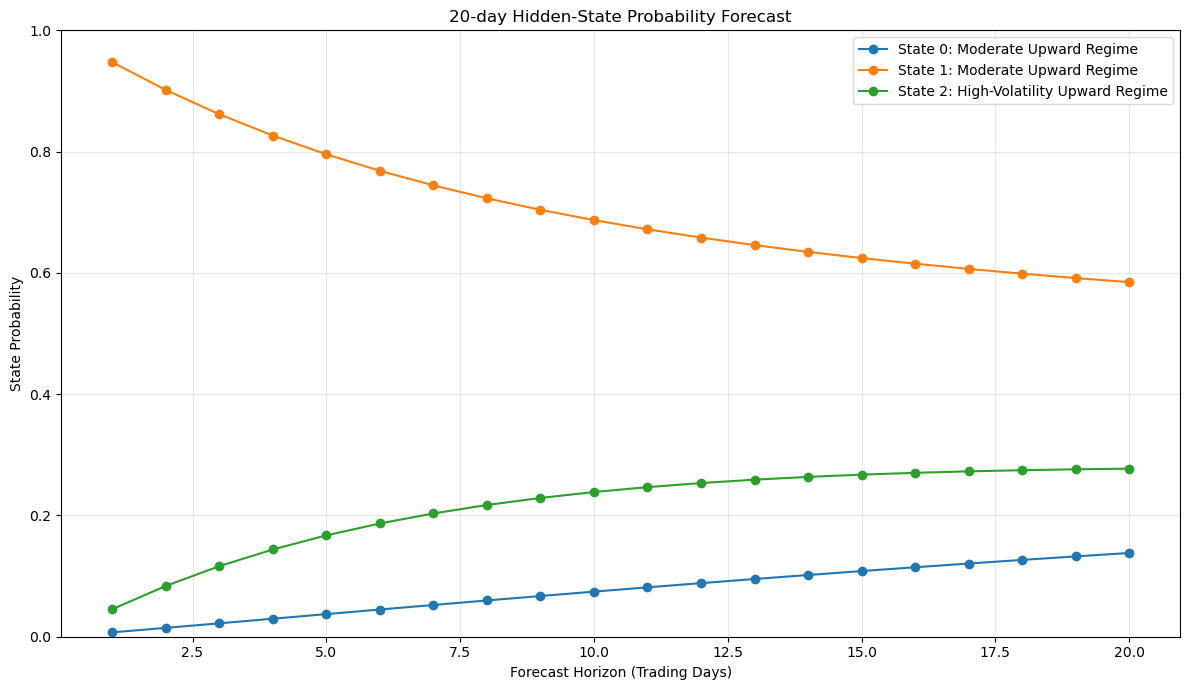


Multi-step forecast saved successfully.


In [17]:
# Chapter 11
# Multi-step Market Regime Forecasting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("Multi-step Market Regime Forecast")
print("=" * 80)

current_state = int(data["State"].iloc[-1])
current_regime = state_labels[current_state]

print(f"\nCurrent State: State {current_state}")
print(f"Current Regime: {current_regime}")

initial_probability = np.zeros(N_STATES)
initial_probability[current_state] = 1.0

print("\nInitial State Probability")
for state in range(N_STATES):
    print(
        f"State {state} ({state_labels[state]}): "
        f"{initial_probability[state]:.4f}"
    )

forecast_days = 20
forecast_results = []

for day in range(1, forecast_days + 1):
    transition_power = np.linalg.matrix_power(
        model.transmat_,
        day
    )

    future_probability = initial_probability @ transition_power
    predicted_state = int(np.argmax(future_probability))
    predicted_regime = state_labels[predicted_state]
    confidence = float(np.max(future_probability))

    result = {
        "Forecast Day": day,
        "Predicted State": predicted_state,
        "Predicted Regime": predicted_regime,
        "Confidence": confidence
    }

    for state in range(N_STATES):
        result[f"State {state} Probability"] = future_probability[state]

    forecast_results.append(result)

forecast_df = pd.DataFrame(forecast_results)

print("\nMulti-step Forecast Result")
print(forecast_df.round(4))

print("\n" + "=" * 80)
print("Readable Forecast Summary")
print("=" * 80)

for _, row in forecast_df.iterrows():
    print(
        f"Day {int(row['Forecast Day'])}: "
        f"State {int(row['Predicted State'])} - "
        f"{row['Predicted Regime']} "
        f"(Confidence: {row['Confidence']:.2%})"
    )

plt.figure(figsize=(12, 7))
for state in range(N_STATES):
    plt.plot(
        forecast_df["Forecast Day"],
        forecast_df[f"State {state} Probability"],
        marker="o",
        label=f"State {state}: {state_labels[state]}"
    )

plt.title("20-day Hidden-State Probability Forecast")
plt.xlabel("Forecast Horizon (Trading Days)")
plt.ylabel("State Probability")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

forecast_df.to_csv(
    "multi_step_state_forecast.csv",
    index=False
)

print("\nMulti-step forecast saved successfully.")